In [1]:
'''
   Copyright 2023-2026 Spacebel s.a.

   Licensed under the Apache License, Version 2.0 (the "License");
   you may not use this file except in compliance with the License.
   You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

   Unless required by applicable law or agreed to in writing, software
   distributed under the License is distributed on an "AS IS" BASIS,
   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
   See the License for the specific language governing permissions and
   limitations under the License.
'''

'\n   Copyright 2023-2026 Spacebel s.a.\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n'

# Use Case - Collection and Granule Search (FedEO)

## Overview

This chapter provides a comprehensive and detailed process about how to implement a CEOS STAC client, which includes how to find collections and granules of interest.

In the examples, we use the `pystac` [[RD17]](#RD17) and `pystac_client` [[RD18]](#RD18) libraries to access the interface. Examples using `curl` on the command-line are provided as well.

In [2]:
%pip install geopandas
# %pip install --force-reinstall -v "pystac_client==0.6.1"
%pip install pystac_client==0.8.5
# %pip install intake

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install folium matplotlib mapclassify
%pip install jsonpath_ng

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import folium
import folium.plugins
import geopandas as gpd
import shapely.geometry
import pandas as pd  
import numpy as np
import json
import urllib.parse
import requests

from xml.dom import minidom
from IPython.display import HTML, display
from IPython.display import Markdown as md
from pystac_client import Client
from pystac import Collection
from typing import Any, Dict
from urllib.parse import urlparse, parse_qsl
from matplotlib import pyplot as plt, cm, colors
from PIL import Image
from io import BytesIO
from branca.element import Figure
from concurrent.futures import ThreadPoolExecutor

import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=UserWarning)


def convert_bounds(bbox, invert_y=False):
    """
    Helper method for changing bounding box representation to leaflet notation

    ``(lon1, lat1, lon2, lat2) -> ((lat1, lon1), (lat2, lon2))``
    """
    x1, y1, x2, y2 = bbox
    if invert_y:
        y1, y2 = y2, y1
    return ((y1, x1), (y2, x2))

def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False
    

def curl_command( url: str, method: str = "GET" ) -> str:
    """
    Convert request URL to equivalent curl GET or POST command-line
    for STAC search (bash shell).
    """
    c = "curl -X " + method
    res = urlparse(url)
    if "GET" in method:
        c = c + " -G " + res.scheme + "://" + res.netloc + res.path
    else:
        c = c + " " + res.scheme + "://" + res.netloc + res.path    \
              + " \\\n\t--header 'Content-Type: application/json'"  \
              + " \\\n\t--data-raw '{"
    
    lst = parse_qsl(res.query)
    
    first = True 
    for i in lst:
        # print(i[0])
        # add \ to end of previous line
        if "GET" in method:
            # correction 16/3: data-urlencode used.
            v = i[1].replace('"','\\"')
            c = c + ' \\\n\t--data-urlencode "'+i[0]+'='+v+'"'
        else:
            if not(first):
                c = c + ','
                
            if i[0] in ["ids","collections"]:
                # "collections" and "ids") parameter has to be included as an array.
                lst = i[1].split(',')       
                c = c + '\n\t\t"'+i[0]+'": '+str(lst).replace("'","\"")
            
            elif is_number(i[1]) or i[1][0]=='{' or i[1][0]=='[':
                # do not surround with quotes if numerical value  or a json object or an array
                c = c + '\n\t\t"'+i[0]+'": '+i[1]
            else:
                c = c + '\n\t\t"'+i[0]+'": "'+i[1]+'"'
        first = False
        
    if "POST" in method:
        c = c + "\n\t}'"
    return c


def display_previews(results):
    """
    Helper method for displaying a grid of quicklooks (if available)
    """
    # create figure
    fig = plt.figure(figsize=(20, 20))
  
    # setting values to rows and column variables for the image grid
    rows = 8
    columns = 2
    pos = 1

    for item in results.items():
        # print(item.id)
        assets = item.assets
        try:
            # print("found thumbnail", assets['thumbnail'].href)
            url = assets['thumbnail'].href
            response = requests.get(url)
            Image1 = Image.open(BytesIO(response.content))
            # display at position 'pos'
            fig.add_subplot(rows, columns, pos)
            pos = pos+1
            # show the image
            plt.imshow(Image1)
            plt.axis('off')
            plt.title(item.id)
        except:
            pass
    return

def display_gdf_plot(results):
    """
    Helper method for displaying results as dataframe plot
    """
    # https://github.com/opendatacube/odc-stac (License Apache 2.0)
    # https://odc-stac.readthedocs.io/en/latest/notebooks/stac-load-e84-aws.html#Plot-STAC-Items-on-a-Map

    # Convert STAC items into a GeoJSON FeatureCollection
    stac_json = results.item_collection_as_dict()

    gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

    fig = gdf.plot(
        "datetime",
        edgecolor="black",
        categorical=True,
        aspect="equal",
        alpha=0.5,
        figsize=(6, 12),
        legend=True,
        legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
    )
    _ = fig.set_title("STAC Query Results")

    # gdf
    return

def display_date_distribution(results):
    """
    Helper method for displaying number of results per year/month as bar chart
    """
    items = list(results.items())
    stac_json = results.item_collection_as_dict()
    gdf = gpd.GeoDataFrame.from_features(stac_json)

    gdf['date'] = pd.to_datetime(gdf['start_datetime'])
    # create a representation of the month with strfmt
    gdf['year_month'] = gdf['date'].map(lambda dt: dt.strftime('%Y-%m'))
    grouped_df = gdf.groupby('year_month')['year_month'].size().to_frame("count").reset_index()
    grouped_df.plot(kind='bar', x='year_month', y='count')
    return

def display_value_distribution(results, column):
    """
    Helper method for displaying number values in column as bar chart
    """
    items = list(results.items())
    stac_json = results.item_collection_as_dict()
    gdf = gpd.GeoDataFrame.from_features(stac_json)

    # gdf['date'] = pd.to_datetime(gdf['start_datetime'])
    # create a representation of the month with strfmt
    # gdf['year_month'] = gdf['date'].map(lambda dt: dt.strftime('%Y-%m'))

    try:
        grouped_df = gdf.groupby(column)[column].size().to_frame("count").reset_index()
        grouped_df.plot(kind='bar', x=column, y='count')
    except:
        print(column + " values are not available.")

    return


def display_map(results):
    """
    Helper method for displaying results on a map
    """
    # https://github.com/python-visualization/folium/issues/1501
    stac_json = results.item_collection_as_dict()
    gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")
    
    fig = Figure(width="800px", height="500px")
    map1 = folium.Map()
    fig.add_child(map1)

    # folium.GeoJson(
    #    shapely.geometry.box(*bbox),  # ??
    #    style_function=lambda x: dict(fill=False, weight=1, opacity=0.7, color="olive"),
    #    name="Query",
    # ).add_to(map1)

    gdf.explore(
        "start_datetime",
        categorical=True,
        tooltip=[
            "title", "datetime", "start_datetime", "platform", "instruments"    
        ],
        popup=True,
        style_kwds=dict(fillOpacity=0.1, width=2),
        name="STAC",
        m=map1,
    )

    # map1.fit_bounds(bounds=convert_bounds(gdf.unary_union.bounds))
    map1.fit_bounds(bounds=convert_bounds(gdf.union_all().bounds))
    display(fig)
    return


In [5]:
URL_LANDING_PAGE =  'https://fedeo.ceos.org/' 

In [6]:
COLLECTION_ID1 = 'PROBA.CHRIS.1A'
COLLECTION_ID2 = 'SPOT-6.and.7.ESA.archive'  
COLLECTION_ID2_CLOUDS = 'LANDSAT.ETM.GTC'
COLLECTION_ID3_CLOUDS = 'IKONOS.ESA.archive'
COLLECTION_ID4 = 'Deimos-1.and.2.ESA.archive' 
COLLECTION_ID5_DMSMM = 'NOAA_AVHRR_L1B_LAC'  # collection with Data Mgt and Stewardship Maturity Matrix


```{index} double: STAC API ; landing page
```

### Access landing page

The landing page provides access to collections (rel="`data`"), child catalogs (rel="`child`") and the STAC item search endpoint (rel="`search`").
Get the catalogue landing page with links to other resources and available collections.

In [7]:
curl_str = curl_command(URL_LANDING_PAGE)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/
```


In [8]:
from pystac_client import Client 

api = Client.open(URL_LANDING_PAGE) 
# show as a dictionary
api.to_dict()

{'type': 'Catalog',
 'id': 'fedeo',
 'stac_version': '1.1.0',
 'description': 'FedEO Clearinghouse provides interoperable access, following ISO/OGC interface guidelines, to Earth Observation metadata',
 'links': [{'rel': 'self',
   'href': 'https://fedeo.ceos.org/',
   'type': 'application/json'},
  {'rel': 'search',
   'href': 'https://fedeo.ceos.org/api?httpAccept=application/opensearchdescription%2Bxml',
   'type': 'application/opensearchdescription+xml',
   'title': 'OpenSearch Description Document'},
  {'rel': 'service-desc',
   'href': 'https://fedeo.ceos.org/api?httpAccept=application/vnd.oai.openapi%2Bjson;version=3.0',
   'type': 'application/vnd.oai.openapi+json;version=3.0',
   'title': 'OpenAPI definition in JSON format'},
  {'rel': 'data',
   'href': 'https://fedeo.ceos.org/collections',
   'type': 'application/json',
   'title': 'Metadata about the feature collections'},
  {'rel': 'data',
   'href': 'https://fedeo.ceos.org/collections',
   'type': 'application/ld+json',
 

```{index} double: pystac_client ; collection search
```
```{index} double: STAC API ; collection search
```
## Collection Search

The API implements the STAC API Collection Search Extension [[RD25]](#RD25).
Available collections can be retrieved from the landing page using a paging mechanism (with rel="`next`" links).  It requires the compliance class to be present.  The Python `requests` library is used in the examples. 

In [9]:
md(f"The collection endpoint is available as rel='`data`' link in the Landing Page.")

The collection endpoint is available as rel='`data`' link in the Landing Page.

In [10]:
from jsonpath_ng.ext import parse

response = requests.get(URL_LANDING_PAGE)
data = json.loads(response.text)
expression = parse("$.links[?(@.rel == 'data')].href")
r = expression.find(data)
r[0].value

'https://fedeo.ceos.org/collections'

In [11]:
# retrieve /collections response
response = requests.get(r[0].value)
data = json.loads(response.text)
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "collections": [
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "license": "various",
         "itemType": "feature",
         "description": "Metadata records representing EO series (a.k.a. EO collections).",
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/series",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/series/items",
               "type": "application/geo+json",
               "title": "Series"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/series?httpAccept=text/html",
               "type": "text/html",
               "title": "Self as HTML"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/series?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "Self as JSON-LD"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/series/queryables",
               "type": "application/schema+json",
               "title": "Queryables for series"
            },
            {
               "rel": "describedBy",
               "href": "http://schemas.opengis.net/eoc-geojson/1.0/eoc-geojson-schema.json",
               "type": "application/schema+json",
               "title": "JSON schema for items belonging to this collection"
            }
         ],
         "id": "series",
         "title": "EO Series",
         "type": "Collection"
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "license": "various",
         "itemType": "feature",
         "description": "Metadata records representing EO datasets (a.k.a. EO products)",
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/datasets",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/datasets/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/datasets?httpAccept=text/html",
               "type": "text/html",
               "title": "Self as HTML"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/datasets?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "Self as JSON-LD"
            },
            {
               "rel": "describedBy",
               "href": "http://schemas.opengis.net/eo-geojson/1.0/eo-geojson-schema.json",
               "type": "application/schema+json",
               "title": "JSON schema for items belonging to this collection"
            }
         ],
         "id": "datasets",
         "title": "EO Products",
         "type": "Collection"
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "license": "various",
         "itemType": "feature",
         "description": "Metadata records representing EO services and applications",
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/services",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/services/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Services and applications"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/services?httpAccept=text/html",
               "type": "text/html",
               "title": "Self as HTML"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/services?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "Self as JSON-LD"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/services/queryables",
               "type": "application/schema+json",
               "title": "Queryables for services"
            },
            {
               "rel": "describedBy",
               "href": "http://schemas.opengis.net/eopad-geojson/1.0/eopad-geojson-schema.json",
               "type": "application/schema+json",
               "title": "JSON schema for items belonging to this collection"
            }
         ],
         "id": "services",
         "title": "EO services and applications",
         "type": "Collection"
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "DIF10",
            "FedEO",
            "THEIA",
            "muscate",
            "level2A",
            "reflectance",
            "landsat",
            "CNES",
            "Geology",
            "Land cover",
            "EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC RADIATION > REFLECTANCE",
            "LANDSAT-5",
            "LANDSAT-7",
            "LANDSAT-8",
            "TM",
            "ETM",
            "OLI"
         ],
         "created": "2015-08-14T00:00:00.00Z",
         "description": "Reflectance Landsat images (Level 2A) processed by the Theia Land Data Center (http://www.theia-land.fr) for the CNES French Space Agency (http://www.cnes.fr). The processing center developed by CNES uses the MACCS prototype L2A chain developed and designed by CESBIO. LANDSAT 8 L1T Input data come from USGS (http://earthexplorer.usgs.gov) that we would like to thank for releasing freely the LANDSAT 8 datasets.",
         "type": "Collection",
         "title": "Landsat Level2A images (Theia)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets search for the series EOP:CNES:THEIA:Landsat"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat/queryables",
               "type": "application/schema+json",
               "title": "Queryables for EOP:CNES:THEIA:Landsat"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:CNES:THEIA:Landsat&subject=Landsat",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "search",
               "href": "https://fedeo.ceos.org/collections/series/items/EOP:CNES:THEIA:Landsat/api?subject=Landsat",
               "type": "application/opensearchdescription+xml",
               "title": "OpenSearch Description Document"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Landsat?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/FR@CNES",
               "title": "More collections for FR/CNES"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/LANDSAT-5",
               "title": "More collections for LANDSAT-5 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/LANDSAT-7",
               "title": "More collections for LANDSAT-7 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/LANDSAT-8",
               "title": "More collections for LANDSAT-8 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/tm",
               "title": "More collections for TM instrument"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/oli",
               "title": "More collections for OLI instrument"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/etm",
               "title": "More collections for ETM instrument"
            }
         ],
         "id": "EOP:CNES:THEIA:Landsat",
         "updated": "2017-04-30T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "producer"
               ],
               "name": "FR/CNES"
            },
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            }
         ],
         "summaries": {
            "instruments": [
               "TM",
               "ETM",
               "OLI"
            ],
            "platform": [
               "LANDSAT-5",
               "LANDSAT-7",
               "LANDSAT-8"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     "2013-07-01T00:00:00.000Z",
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "EO IPT",
            "Poland",
            "FedEO",
            "OGC Testbed-14",
            "DIF10",
            "soil",
            "landscape",
            "vegetation",
            "Science Keywords > Earth Science > Spectral/Engineering > Visible Wavelengths > Visible Imagery",
            "Science Keywords > Earth Science > Spectral/Engineering > Infrared Wavelengths > Thermal Infrared",
            "TIRS"
         ],
         "created": "2017-04-15T00:00:00.00Z",
         "description": " Landsat-8 products stored in the catalog provided by the Earth Observation Innovative Platform Testbed Poland. Landsat 8 level 1 products combine data from the 2 Landsat instruments; OLI and TIRS. The level 1 products generated can be either L1T or L1gT. \t\t\t\tLevel 1T data products consist of radiometrically corrected image data derived from L0 data scaled to at-aperture spectral radiance or reflectance that are resampled for registration to a cartographic projection (referenced to the WGS84, G873 or current version). The L1T product is orthorectified, and corrected for terrain relief. The geometric corrections use observatory ephemeris data and ground control points; DEM data is used to correct for terrain relief.\t\t\t\tGeometrically corrected products L1gT data products consist of L0 product data with systematic radiometric, geometric and terrain corrections applied and resampled for registration to a cartographic projection, referenced to the WGS84, G873, or current version. L1gT data products assume the use of on-board positional information or definitive ephemeris, as well as the use of controlled elevation data to correct for parallax errors. In case of insufficient GCP, caused by extensive snow/cloud cover, which makes the orthorectification impossible, products of this level are produced instead of L1T.\t\t\t\t",
         "type": "Collection",
         "title": "Landsat-8 Collection (EO IPT.PL)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets search for the series EOP:IPT:Landsat8"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8/queryables",
               "type": "application/schema+json",
               "title": "Queryables for EOP:IPT:Landsat8"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:IPT:Landsat8&sensorType=OPTICAL",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "search",
               "href": "https://fedeo.ceos.org/collections/series/items/EOP:IPT:Landsat8/api?sensorType=OPTICAL",
               "type": "application/opensearchdescription+xml",
               "title": "OpenSearch Description Document"
            },
            {
               "rel": "describedby",
               "href": "https://earth.esa.int/web/guest/-/landsat-oli-tirs-european-coverage"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:IPT:Landsat8?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/CloudFerro",
               "title": "More collections for CloudFerro"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/Landsat-8",
               "title": "More collections for Landsat-8 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/tirs",
               "title": "More collections for TIRS instrument"
            }
         ],
         "id": "EOP:IPT:Landsat8",
         "updated": "2017-04-30T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "producer"
               ],
               "name": "CloudFerro"
            },
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            }
         ],
         "summaries": {
            "instruments": [
               "TIRS"
            ],
            "platform": [
               "Landsat-8"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "FedEO",
            "DIF10",
            "THEIA",
            "spotworldheritage",
            "level2A",
            "reflectance",
            "spot",
            "CNES",
            "Geology",
            "Land cover",
            "EARTH SCIENCE > LAND USE/LAND COVER",
            "SPOT 1",
            "SPOT 2",
            "SPOT 4",
            "SPOT 5",
            "HRV",
            "HRVIR",
            "HRG",
            "HRS"
         ],
         "created": "2015-08-14T00:00:00.00Z",
         "description": "Multispectral decametric images from the Spot 1-5 archive of more than 5 years old, acquired in the framework of the Spot World Heritage programme, based on a partnership between CNES and Airbus Defence and Space. The images are available on a free and open basis for any user, provided usage is non-commercial",
         "type": "Collection",
         "title": "SpotWorldHeritage (Theia)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets search for the series EOP:CNES:THEIA:SpotWorldHeritage"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage/queryables",
               "type": "application/schema+json",
               "title": "Queryables for EOP:CNES:THEIA:SpotWorldHeritage"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:CNES:THEIA:SpotWorldHeritage&sensorType=OPTICAL&subject=SpotWorldHeritage",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "search",
               "href": "https://fedeo.ceos.org/collections/series/items/EOP:CNES:THEIA:SpotWorldHeritage/api?sensorType=OPTICAL&subject=SpotWorldHeritage",
               "type": "application/opensearchdescription+xml",
               "title": "OpenSearch Description Document"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:SpotWorldHeritage?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/FR@CNES",
               "title": "More collections for FR/CNES"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/SPOT%201",
               "title": "More collections for SPOT 1 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/SPOT%202",
               "title": "More collections for SPOT 2 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/SPOT%204",
               "title": "More collections for SPOT 4 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/SPOT%205",
               "title": "More collections for SPOT 5 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/hrs",
               "title": "More collections for HRS instrument"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/hrvir",
               "title": "More collections for HRVIR instrument"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/hrv",
               "title": "More collections for HRV instrument"
            }
         ],
         "id": "EOP:CNES:THEIA:SpotWorldHeritage",
         "updated": "2017-04-30T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "producer"
               ],
               "name": "FR/CNES"
            },
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            }
         ],
         "summaries": {
            "instruments": [
               "HRV",
               "HRV",
               "HRVIR",
               "HRS"
            ],
            "platform": [
               "SPOT 1",
               "SPOT 2",
               "SPOT 4",
               "SPOT 5"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     null,
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "FedEO",
            "DIF10",
            "THEIA",
            "spirit",
            "polar",
            "LEGOS",
            "SPOT5",
            "IGN",
            "Astrium",
            "CNES",
            "Geology",
            "Land cover",
            "EARTH SCIENCE > CRYOSPHERE > GLACIERS/ICE SHEETS",
            "SPOT 5",
            "HRS"
         ],
         "created": "2015-08-14T00:00:00.00Z",
         "description": "Astrium Services and CNES supplied satellite data for the international Polar Year research programmes. Earth-observing satellites are mapping the poles to provide scientists with a more precise picture of how glaciers are changing and to help them understand the impacts of climate change on our planet. Astrium Services and CNES joined the SPIRIT project (SPOT 5 stereoscopic survey of Polar Ice: Reference Images and Topographies) in partnership with French survey, the French mapping agency IGN and the LEGOS, space geophysics and oceanography research laboratory. During two years, from 2007 to 2009, an archive of SPOT 5 HRS images was compiled over polar ice in order to produce DTMs and ortho-image",
         "type": "Collection",
         "title": "SPOT5 stereoscopic survey of Polar Ice (Theia)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets search for the series EOP:CNES:THEIA:Spirit"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit/queryables",
               "type": "application/schema+json",
               "title": "Queryables for EOP:CNES:THEIA:Spirit"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:CNES:THEIA:Spirit&sensorType=OPTICAL&subject=Spirit",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "search",
               "href": "https://fedeo.ceos.org/collections/series/items/EOP:CNES:THEIA:Spirit/api?sensorType=OPTICAL&subject=Spirit",
               "type": "application/opensearchdescription+xml",
               "title": "OpenSearch Description Document"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:THEIA:Spirit?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/FR@CNES",
               "title": "More collections for FR/CNES"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/SPOT%205",
               "title": "More collections for SPOT 5 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/hrs",
               "title": "More collections for HRS instrument"
            }
         ],
         "id": "EOP:CNES:THEIA:Spirit",
         "updated": "2017-04-30T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "producer"
               ],
               "name": "FR/CNES"
            },
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            }
         ],
         "summaries": {
            "instruments": [
               "HRS"
            ],
            "platform": [
               "SPOT 5"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     "2015-06-23T00:00:00.000Z",
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "FedEO",
            "DIF10",
            "THEIA",
            "PEPS",
            "CNES",
            "optical",
            "sentinel2",
            "EARTH SCIENCE > LAND USE/LAND COVER",
            "land",
            "land cover",
            "chlorophyll",
            "natural disaster",
            "Sentinel-2",
            "MSI"
         ],
         "created": "2015-06-23T00:00:00.00Z",
         "description": "The SENTINEL-2 mission is a land monitoring constellation of two satellites each equipped with a MSI (Multispectral Imager) instrument covering 13 spectral bands providing high resolution optical imagery (i.e., 10m, 20m, 60 m) every 10 days with one satellite and 5 days with two satellites.",
         "type": "Collection",
         "title": "Sentinel-2 (PEPS)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "items",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json",
               "title": "Datasets search for the series EOP:CNES:PEPS:S2"
            },
            {
               "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2/queryables",
               "type": "application/schema+json",
               "title": "Queryables for EOP:CNES:PEPS:S2"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:CNES:PEPS:S2&sensorType=OPTICAL&platform=S2A",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "search",
               "href": "https://fedeo.ceos.org/collections/series/items/EOP:CNES:PEPS:S2/api?sensorType=OPTICAL&platform=S2A",
               "type": "application/opensearchdescription+xml",
               "title": "OpenSearch Description Document"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/EOP:CNES:PEPS:S2?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/FR@CNES",
               "title": "More collections for FR/CNES"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/Sentinel-2",
               "title": "More collections for Sentinel-2 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/s2-msi",
               "title": "More collections for MSI instrument"
            }
         ],
         "id": "EOP:CNES:PEPS:S2",
         "updated": "2017-04-30T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "producer"
               ],
               "name": "FR/CNES"
            },
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            }
         ],
         "summaries": {
            "instruments": [
               "MSI"
            ],
            "platform": [
               "Sentinel-2"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     "2013-10-01T00:00:00.000Z",
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "Environmental   Satellite",
            "Russian   Space   Program",
            "RUSSIA/ROSCOSMOS",
            "CEOS",
            "Science Keywords > Earth Science > Spectral/Engineering > Infrared Wavelengths > Infrared Imagery",
            "Science Keywords > Earth Science > Spectral/Engineering > Visible Wavelengths > Visible Imagery",
            "RESURS-P2",
            "SHMSA_VR"
         ],
         "description": "This collection provides access to SHMSA-VR multispectral images from Resurs-P N2 archived at ROSCOSMOS.",
         "type": "Collection",
         "title": "SHMSA-VR multispectral images   from Resurs-P N2 (ROSCOSMOS)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:ROSCOSMOS&platform=714&instrument=62%2C63",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "describedby",
               "href": "http://gptl.ru"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP2_SVR?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/ROSCOSMOS",
               "title": "More collections for ROSCOSMOS"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/RESURS-P2",
               "title": "More collections for RESURS-P2 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/72f5b059-bc48-4ed2-960f-62b83b74782a",
               "title": "More collections for SHMSA_VR instrument"
            }
         ],
         "id": "RP2_SVR",
         "updated": "2015-09-11T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            },
            {
               "roles": [
                  "producer"
               ],
               "name": "ROSCOSMOS"
            }
         ],
         "summaries": {
            "instruments": [
               "SHMSA_VR"
            ],
            "platform": [
               "RESURS-P2"
            ]
         }
      },
      {
         "extent": {
            "spatial": {
               "bbox": [
                  [
                     -180,
                     -90,
                     180,
                     90
                  ]
               ]
            },
            "temporal": {
               "interval": [
                  [
                     "2013-06-25T00:00:00.000Z",
                     null
                  ]
               ]
            }
         },
         "stac_version": "1.0.0",
         "keywords": [
            "Environmental   Satellite",
            "Russian   Space   Program",
            "RUSSIA/ROSCOSMOS",
            "CEOS",
            "Science Keywords > Earth Science > Spectral/Engineering > Infrared Wavelengths > Infrared Imagery",
            "Science Keywords > Earth Science > Spectral/Engineering > Visible Wavelengths > Visible Imagery",
            "RESURS-P1",
            "GSA"
         ],
         "description": "This collection provides access to  Hyperspectral   images   from   Resurs-P   N1 archived at ROSCOSMOS.",
         "type": "Collection",
         "title": "Hyperspectral imaging from   Resurs-P N1 (ROSCOSMOS)",
         "license": "various",
         "assets": {
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_iso_19139_2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/vnd.iso.19139-2%2Bxml",
               "title": "ISO 19139-2 metadata",
               "type": "application/vnd.iso.19139-2+xml"
            },
            "metadata_dif_10": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/dif10%2Bxml",
               "title": "DIF-10 metadata",
               "type": "application/dif10+xml"
            },
            "metadata_ogc_17_084r1": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?mode=owc",
               "title": "OGC 17-084r1 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "metadata_iso_191115_3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/vnd.iso.19115-3%2Bxml",
               "title": "ISO 19115-3 metadata",
               "type": "application/vnd.iso.19115-3+xml"
            }
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA",
               "type": "application/json"
            },
            {
               "rel": "root",
               "href": "https://fedeo.ceos.org",
               "type": "application/json",
               "title": "FedEO Clearinghouse"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org",
               "title": "collections",
               "type": "application/json"
            },
            {
               "rel": "search",
               "href": "https://fedeo.esa.int/opensearch/description.xml?parentIdentifier=EOP:ROSCOSMOS&platform=10&instrument=28",
               "title": "FedEO Clearinghouse - FedEO Clearinghouse"
            },
            {
               "rel": "describedby",
               "href": "http://gptl.ru"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/xml",
               "type": "application/xml",
               "title": "Dublin Core metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/RP1_GSA?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:organisationName/ROSCOSMOS",
               "title": "More collections for ROSCOSMOS"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/series/eo:platform/RESURS-P1",
               "title": "More collections for RESURS-P1 platform"
            },
            {
               "rel": "related",
               "href": "https://fedeo.ceos.org/concepts/instruments/10deaf31-ae63-43a6-90b8-994487a71edb",
               "title": "More collections for GSA instrument"
            }
         ],
         "id": "RP1_GSA",
         "updated": "2015-09-11T00:00:00.00Z",
         "providers": [
            {
               "roles": [
                  "host"
               ],
               "name": "FedEO",
               "url": "https://fedeo.ceos.org/readme.html"
            },
            {
               "roles": [
                  "producer"
               ],
               "name": "ROSCOSMOS"
            }
         ],
         "summaries": {
            "instruments": [
               "GSA"
            ],
            "platform": [
               "RESURS-P1"
            ]
         }
      }
   ],
   "numberReturned": 10,
   "links": [
      {
         "rel": "self",
         "href": "https://fedeo.ceos.org/collections",
         "type": "application/json",
         "title": "This document"
      },
      {
         "rel": "next",
         "href": "https://fedeo.ceos.org/collections?startRecord=11",
         "type": "application/json",
         "title": "Next results"
      },
      {
         "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
         "href": "https://fedeo.ceos.org/collections/queryables",
         "type": "application/schema+json",
         "title": "Queryables for collection search"
      }
   ],
   "numberMatched": 3258
}
```


The link with rel="http://www.opengis.net/def/rel/ogc/1.0/queryables" provides access to the list of filter criteria available for collection search.  It returns a Queryables object in JSON Schema format.

In [12]:
from jsonpath_ng.ext import parse

expression = parse("$.links[?(@.rel == 'http://www.opengis.net/def/rel/ogc/1.0/queryables')].href")
r = expression.find(data)
r[0].value

'https://fedeo.ceos.org/collections/queryables'

In [13]:
# Get queryables response and list parameters alphabetically.
response = requests.get(r[0].value)
data = json.loads(response.text)    
df = pd.DataFrame(data['properties'].items(),columns=['key','value'])
df['type'] = df.apply(lambda row : row['value']['type'], axis = 1)
df['format'] = df.apply(lambda row : row['value']['format'] if 'format' in row['value'] else '-' , axis = 1)
df.drop('value',axis=1).sort_values(by=['key'])

,key,type,format
14,classifiedAs,string,uri
13,doi,string,-
3,instrument,string,-
8,modificationDate,string,date-time
11,offering,string,-
7,organisationName,string,-
5,otherConstraint,string,-
2,parentIdentifier,string,-
6,platform,string,-
9,processingLevel,string,-


In [14]:
URL_LANDING_PAGE

'https://fedeo.ceos.org/'

The STAC API Collection Search Extension [[RD25]](#RD25) allows retrieving the collections at the `/collections` endpoint.
List available collections using `curl`:

In [15]:
curl_str = curl_command(URL_LANDING_PAGE+"collections")
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections
```


### Search by free text

**Example: 1.1**  
>  Search collections by free text (`q`).  

In [16]:
from pystac_client import Client
api = Client.open(URL_LANDING_PAGE)

results = api.collection_search(
    q = 'Seasat'
)

In [17]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "q=Seasat"
```


In [18]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'keywords']]

,id,keywords
0,SeaSat.ESA.archive,"[DIF10, EARTH SCIENCE>OCEANS, EARTH SCIENCE>OC..."


### Search by title

**Example: 1.2**  
>  Search collections by title (`filter` and `title`). 

In [19]:
# CQL2 Basic only supports "=" operator for strings, thus complete title has to be provided.
# Future versions may support "Advanced Comparison Operators". 
value = 'ALOS PALSAR products'

results = api.collection_search(
    filter = "title='" + value + "'"
)

In [20]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=title='ALOS PALSAR products'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [21]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])

df[['id', 'title']]
# df

,id,title
0,ALOS.PALSAR.FBS.FBD.PLR.products,ALOS PALSAR products


### Search by platform

**Example: 1.3**  
>  Search collections by platform (`filter` and `platform`).  

In [22]:
value = 'PROBA-1'

results = api.collection_search(
    filter = "platform='" + value + "'"
)

In [23]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=platform='PROBA-1'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [24]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['title', 'summaries.platform']]

,title,summaries.platform
0,Proba CHRIS Level 1A,[PROBA-1]
1,Proba HRC,[PROBA-1]


### Search by organisation

**Example: 1.4**  
>  Search collections by organisation (`filter`). 

In [154]:
# value = 'ESA/ESRIN'
value = 'BR/INPE'

results = api.collection_search(
    filter = "organisationName='" + value + "'"
)

In [155]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=organisationName='BR/INPE'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [156]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['title', 'providers']]

,title,providers
0,CBERS-4/MUX - Level-4-DN,"[{'processing:level': 'L4 DN', 'roles': ['prod..."
1,Landsat Collection 2 - Level-2,"[{'roles': ['producer', 'licensor'], 'name': '..."
2,Landsat 6M São Paulo State Mosaic,"[{'processing:level': 'L2', 'roles': ['host', ..."
3,CBERS-4/MUX - Level-2-DN,"[{'processing:level': 'L2 DN', 'roles': ['prod..."
4,CBERS/WFI - Level-4-SR - Data Cube - LCF 8 days,"[{'processing:level': 'L4', 'roles': ['host', ..."
...,...,...
79,S2 2M Cerrado Biome Mosaic,"[{'roles': ['producer', 'licensor'], 'name': '..."
80,S2 3M Paraiba State Mosaic,"[{'roles': ['producer', 'licensor'], 'name': '..."
81,MERGE - Hourly Gridded Precipitation over Sout...,"[{'roles': ['producer'], 'name': 'Japan Aerosp..."
82,AMAZONIA-1/WFI Image Mosaic of Brazil - 3 Months,"[{'processing:level': 'L4', 'roles': ['host', ..."


### Search by bounding box

**Example: 1.5**  
>  Search collections by bounding box (`bbox`). 

In [28]:
results = api.collection_search(
    bbox = "14.90,37.700,14.99,37.780",
    max_collections = 5,
    limit = 5
)

In [29]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "limit=5" \
	--data-urlencode "bbox=14.9,37.7,14.99,37.78"
```


In [30]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'extent.spatial.bbox']]

,id,extent.spatial.bbox
0,EOP:CNES:THEIA:Landsat,"[[-180, -90, 180, 90]]"
1,EOP:IPT:Landsat8,"[[-180, -90, 180, 90]]"
2,EOP:CNES:THEIA:SpotWorldHeritage,"[[-180, -90, 180, 90]]"
3,EOP:CNES:THEIA:Spirit,"[[-180, -90, 180, 90]]"
4,EOP:CNES:PEPS:S2,"[[-180, -90, 180, 90]]"


### Search by temporal extent

**Example: 1.6**  
>  Search collections by temporal extent (`datetime` with closed range). 

In [31]:
results = api.collection_search(
    datetime = '2002-01-01T00:00:00.000Z/2003-12-31T23:59:59.999Z',
    max_collections = 5,
    limit = 5
)

In [32]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "limit=5" \
	--data-urlencode "datetime=2002-01-01T00:00:00.000Z/2003-12-31T23:59:59.999Z"
```


In [33]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'extent.temporal.interval']]

,id,extent.temporal.interval
0,SPOT,"[[1986-02-22T00:00:00.000Z, None]]"
1,M3M1,"[[2001-12-10T00:00:00.000Z, None]]"
2,ERS-2,"[[1995-04-21T00:00:00.000Z, 2011-09-05T23:59:5..."
3,SST_BS_PHY_L3S_MY_010_041,"[[1981-08-25T00:00:00.000Z, None]]"
4,MEDSEA_OMI_TEMPSAL_sst_area_averaged_anomalies,"[[1993-01-01T00:00:00.000Z, None]]"


**Example: 1.7**  
>  Search collections by temporal extent (`datetime` with open range). 

In [34]:
results = api.collection_search(
    datetime = '../2001-12-31T23:59:59.999Z',
    max_collections = 5,
    limit = 5
)

In [35]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "limit=5" \
	--data-urlencode "datetime=../2001-12-31T23:59:59.999Z"
```


In [36]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'extent.temporal.interval']]

,id,extent.temporal.interval
0,SPOT,"[[1986-02-22T00:00:00.000Z, None]]"
1,M3M1,"[[2001-12-10T00:00:00.000Z, None]]"
2,ERS-2,"[[1995-04-21T00:00:00.000Z, 2011-09-05T23:59:5..."
3,SST_BS_PHY_L3S_MY_010_041,"[[1981-08-25T00:00:00.000Z, None]]"
4,MEDSEA_OMI_TEMPSAL_sst_area_averaged_anomalies,"[[1993-01-01T00:00:00.000Z, None]]"


**Example: 1.8**  
>  Search collections by temporal extent (`datetime` with single date).

In [37]:
results = api.collection_search(
    datetime = '2002-12-31T23:59:59.999Z',
    max_collections = 5,
    limit = 5
)

In [38]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "limit=5" \
	--data-urlencode "datetime=2002-12-31T23:59:59.999Z"
```


In [39]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'extent.temporal.interval']]

,id,extent.temporal.interval
0,SPOT,"[[1986-02-22T00:00:00.000Z, None]]"
1,M3M1,"[[2001-12-10T00:00:00.000Z, None]]"
2,ERS-2,"[[1995-04-21T00:00:00.000Z, 2011-09-05T23:59:5..."
3,SST_BS_PHY_L3S_MY_010_041,"[[1981-08-25T00:00:00.000Z, None]]"
4,MEDSEA_OMI_TEMPSAL_sst_area_averaged_anomalies,"[[1993-01-01T00:00:00.000Z, None]]"


### Get by identifier

**Example: 1.9**  
>  Get collections by identifier (`ids`). 

In [40]:
URL = URL_LANDING_PAGE + 'collections?ids=' + COLLECTION_ID1 + ',' + COLLECTION_ID2

In [41]:
curl_str = curl_command(URL)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "ids=PROBA.CHRIS.1A,SPOT-6.and.7.ESA.archive"
```


In [42]:
response = requests.get(URL)
data = json.loads(response.text)

df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'title', 'extent.temporal.interval']]

,id,title,extent.temporal.interval
0,PROBA.CHRIS.1A,Proba CHRIS Level 1A,"[[2002-05-14T00:00:00.000Z, 2022-12-22T00:00:0..."
1,SPOT-6.and.7.ESA.archive,SPOT-6 and 7 ESA archive,"[[2012-10-01T00:00:00.000Z, None]]"


**Example: 1.10**  
>  Get collection by identifier.  

In [43]:
md(f"The collection metadata for `{COLLECTION_ID1}`, is available at  \
at {URL_LANDING_PAGE + 'collections/' + COLLECTION_ID1}.  This corresponds to one of the many representations available at {URL_LANDING_PAGE + 'collections/series/items/' + COLLECTION_ID1} using content-negotiation.")

The collection metadata for `PROBA.CHRIS.1A`, is available at  at https://fedeo.ceos.org/collections/PROBA.CHRIS.1A.  This corresponds to one of the many representations available at https://fedeo.ceos.org/collections/series/items/PROBA.CHRIS.1A using content-negotiation.

In [44]:
URL = URL_LANDING_PAGE + 'collections/' + COLLECTION_ID1

In [45]:
curl_str = curl_command(URL)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections/PROBA.CHRIS.1A
```


In [46]:
# retrieve collection by identifier
response = requests.get(URL)
data = json.loads(response.text)

print("id: ", data['id'])
print("title: ", data['title'])
df = pd.json_normalize(data, max_level = 0)
df.transpose()

id:  PROBA.CHRIS.1A
title:  Proba CHRIS Level 1A


,0
extent,"{'spatial': {'bbox': [[-180, -56, 180, 75]]}, ..."
stac_version,1.0.0
keywords,"[DIF10, EARTH SCIENCE>BIOSPHERE>ECOSYSTEMS>TER..."
created,2019-05-22T00:00:00.00Z
description,CHRIS acquires a set of up to five images of e...
type,Collection
title,Proba CHRIS Level 1A
license,other
assets,"{'enclosure': {'roles': ['data'], 'href': 'htt..."
links,"[{'rel': 'related', 'href': 'https://fedeo.ceo..."


In [47]:
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "extent": {
      "spatial": {
         "bbox": [
            [
               -180,
               -56,
               180,
               75
            ]
         ]
      },
      "temporal": {
         "interval": [
            [
               "2002-05-14T00:00:00.000Z",
               "2022-12-22T23:59:59.999Z"
            ]
         ]
      }
   },
   "stac_version": "1.0.0",
   "keywords": [
      "DIF10",
      "EARTH SCIENCE>BIOSPHERE>ECOSYSTEMS>TERRESTRIAL ECOSYSTEMS>FORESTS",
      "EARTH SCIENCE>BIOSPHERE>VEGETATION",
      "EARTH SCIENCE>TERRESTRIAL HYDROSPHERE>SURFACE WATER",
      "EARTH SCIENCE>OCEANS",
      "PROBA-1",
      "PROBA.CHRIS",
      "Orthoimagery",
      "Forestry",
      "Vegetation",
      "Surface Water",
      "Oceans",
      "VIS (0.40 - 0.75) \u00b5m",
      "NIR (0.75 - 1.30) \u00b5m",
      "Sun-synchronous",
      "High Resolution - HR (5 - 20) m",
      "Medium Resolution - MR (20 - 500) m",
      "CHR_MO1_1P",
      "CHR_MO2_1P",
      "CHR_MO3_1P",
      "CHR_MO4_1P",
      "CHR_MO5_1P",
      "615 km",
      "14 km",
      "Imaging Spectrometers/Radiometers",
      "PUBLIC",
      "ESA_open_and_free",
      "CHRIS"
   ],
   "created": "2019-05-22T00:00:00.00Z",
   "description": "CHRIS acquires a set of up to five images of each target during each acquisition sequence, these images are acquired when Proba-1 is pointing at distinct angles with respect to the target. CHRIS Level 1A products (supplied in HDF data files, version 4.1r3) include five formal CHRIS imaging modes, classified as modes 1 to 5: \u2022 MODE 1: Full swath width, 62 spectral bands, 773nm / 1036nm, nadir ground sampling distance 34m @ 556km \u2022 MODE 2 WATER BANDS: Full swath width, 18 spectral bands, nadir ground sampling distance 17m @ 556km \u2022 MODE 3 LAND CHANNELS: Full swath width, 18 spectral bands, nadir ground sampling distance 17m @ 556km \u2022 MODE 4 CHLOROPHYL BAND SET: Full swath width, 18 spectral bands, nadir ground sampling distance 17m @ 556km \u2022 MODE 5 LAND CHANNELS: Half swath width, 37 spectral bands, nadir ground sampling distance 17m @ 556km All Proba-1 passes are systematically acquired according to the current acquisition plan, CHRIS data are processed every day to Level 1A and made available to ESA users. Observation over a new specific area can be performed by submitting the request to add a new site to the acquisition plan. Valuable indication whether the acquisition was successfully, cloudy, failed or programmed is reported in the _$$Proba-CHRIS Actual Acquisitions$$ http://www.rsacl.co.uk/chris/excel/active/",
   "type": "Collection",
   "title": "Proba CHRIS Level 1A",
   "license": "other",
   "assets": {
      "enclosure": {
         "roles": [
            "data"
         ],
         "href": "https://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/index/",
         "type": "text/html",
         "title": "OADS repository - OADS repository"
      },
      "metadata_ogc_17_069r3": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A",
         "title": "OGC 17-069r3 metadata",
         "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
      },
      "metadata_iso_19139": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19139%2Bxml",
         "title": "ISO 19139 metadata",
         "type": "application/vnd.iso.19139+xml"
      },
      "metadata_iso_19139_2": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19139-2%2Bxml",
         "title": "ISO 19139-2 metadata",
         "type": "application/vnd.iso.19139-2+xml"
      },
      "metadata_dif_10": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/dif10%2Bxml",
         "title": "DIF-10 metadata",
         "type": "application/dif10+xml"
      },
      "metadata_ogc_17_084r1": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?mode=owc",
         "title": "OGC 17-084r1 metadata",
         "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
      },
      "metadata_html": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=text/html",
         "title": "HTML",
         "type": "text/html"
      },
      "metadata_iso_191115_3": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19115-3%2Bxml",
         "title": "ISO 19115-3 metadata",
         "type": "application/vnd.iso.19115-3+xml"
      }
   },
   "links": [
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/series/eo:platform/PROBA-1",
         "title": "More collections for PROBA-1 platform"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/concepts/instruments/6b0bdcea-3beb-58ab-80f3-4fc5961d99e1",
         "title": "More collections for CHRIS instrument"
      },
      {
         "rel": "self",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A",
         "type": "application/json"
      },
      {
         "rel": "root",
         "href": "https://fedeo.ceos.org",
         "type": "application/json",
         "title": "FedEO Clearinghouse"
      },
      {
         "rel": "parent",
         "href": "https://fedeo.ceos.org",
         "title": "collections",
         "type": "application/json"
      },
      {
         "rel": "items",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
         "type": "application/geo+json",
         "title": "Datasets search for the series PROBA.CHRIS.1A"
      },
      {
         "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/queryables",
         "type": "application/schema+json",
         "title": "Queryables for PROBA.CHRIS.1A"
      },
      {
         "rel": "search",
         "href": "https://fedeo.ceos.org/collections/series/items/PROBA.CHRIS.1A/api",
         "type": "application/opensearchdescription+xml",
         "title": "OpenSearch Description Document"
      },
      {
         "rel": "describedby",
         "href": "https://earth.esa.int/c/document_library/get_file?folderId=23844&name=DLFE-592.pdf",
         "type": "application/pdf",
         "title": "CHRIS Data Format - Product Specifications"
      },
      {
         "rel": "describedby",
         "href": "https://earth.esa.int/eogateway/documents/20142/37627/Note%20on%20CHRIS%20Acquisition%20Procedure%20and%20Image%20Geometry",
         "type": "application/pdf",
         "title": "Note on CHRIS Acquisition Procedure and Image Geometry - Technical Note"
      },
      {
         "rel": "describedby",
         "href": "https://earth.esa.int/eogateway/search?category=tools+and+toolboxes&mission=proba-1&tools_type=analysis%2Cprocessing",
         "type": "text/html",
         "title": "PROBA Chris Software Tool - Software Tools"
      },
      {
         "rel": "describedby",
         "href": "https://esatellus.service-now.com/csp?id=esa_simple_request&sys_id=f27b38f9dbdffe40e3cedb11ce961958",
         "type": "text/html",
         "title": "Get Help? - ESA Earth Observation User Services Portal"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/atom%2Bxml",
         "type": "application/atom+xml",
         "title": "Atom format"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/xml",
         "type": "application/xml",
         "title": "Dublin Core metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/ld%2Bjson",
         "type": "application/ld+json",
         "title": "JSON-LD metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/ld%2Bjson;profile=https://schema.org",
         "type": "application/ld+json;profile=\"https://schema.org\"",
         "title": "JSON-LD (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
         "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
         "title": "JSON-LD (GeoDCAT-AP) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/rdf%2Bxml",
         "type": "application/rdf+xml",
         "title": "RDF/XML metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
         "type": "application/rdf+xml;profile=\"https://schema.org\"",
         "title": "RDF/XML (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
         "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
         "title": "RDF/XML (GeoDCAT-AP) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=text/turtle",
         "type": "text/turtle",
         "title": "Turtle metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=text/turtle;profile=https://schema.org",
         "type": "text/turtle;profile=\"https://schema.org\"",
         "title": "Turtle (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
         "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
         "title": "Turtle (GeoDCAT-AP) metadata"
      }
   ],
   "id": "PROBA.CHRIS.1A",
   "updated": "2026-06-08T07:23:36Z",
   "stac_extensions": [
      "https://stac-extensions.github.io/processing/v1.1.0/schema.json"
   ],
   "providers": [
      {
         "roles": [
            "producer"
         ],
         "name": "ESA/ESRIN",
         "url": "http://www.esa.int"
      },
      {
         "roles": [
            "host"
         ],
         "name": "FedEO",
         "url": "https://fedeo.ceos.org/readme.html"
      }
   ],
   "summaries": {
      "processing:level": [
         "L1A"
      ],
      "instruments": [
         "CHRIS"
      ],
      "platform": [
         "PROBA-1"
      ]
   }
}
```


### Search by DOI

**Example: 1.11**  
>  Search collections by DOI (`filter` with `doi`). 

In [48]:
value = '10.5270/esa-qoe849q'

results = api.collection_search(
    filter = "doi = '" + value + "'"
)

In [49]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=doi = '10.5270/esa-qoe849q'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [50]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'title']]

,id,title
0,TropForest,"TropForest- ALOS, GEOSAT-1 & KOMPSAT-2 optical..."



### Search by concept

**Example: 1.12**  
>  Search collections by concept URI (`filter` with `classifiedAs`). 


Collection metadata includes platform, instrument and science keywords, including the URI of these concepts expressed in the ESA thesauri and NASA GCMD thesauri.  The URI of these concepts can be used as search parameter.  

In the current version of the software, the following concept URIs are supported:

* ESA thesaurus platform URI
* ESA thesaurus instrument URI
* ESA thesaurus earth topic URI
* GCMD platform URI
* GCMD instrument URI
* GCMD science keyword URI

In [51]:
# Concept defining PROBA-1
# https://gcmd.earthdata.nasa.gov/kms/concept/fe4a4604-029e-4cdc-93f0-6d8799dd25e5
# Concept defining ENVISAT
# https://gcmd.earthdata.nasa.gov/kms/concept/11ea961b-1d0b-5d6d-a55a-b58aed01d430

concept_uri = 'https://earth.esa.int/concept/b3979ff2-d27d-5f22-9e06-a18c5759d9a5'

results = api.collection_search(
    filter = "classifiedAs = '" + concept_uri + "'"
)

In [52]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=classifiedAs = 'https://earth.esa.int/concept/b3979ff2-d27d-5f22-9e06-a18c5759d9a5'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [53]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'title']]

,id,title
0,PROBA.CHRIS.1A,Proba CHRIS Level 1A
1,PROBA.HRC.1A,Proba HRC


In [54]:
# Get more details about the ESA Thesauri concept via the SPARQL interface.
# Make SPARQL request to obtain concept details.
#q="DESCRIBE <" + concept_uri + "> WHERE { }"
#response = requests.post(
#    'https://eovoc.spacebel.be/thesaurus/sparql', 
#    data=q, headers={'content-type': 'application/sparql-query', 'Accept': 'application/ld+json'})
# Can also use application/rdf+xml
#jstr = response.text
#md("```json\n" + jstr + "\n```\n")


In [55]:
# Concept defining PROBA-1
concept_uri = 'https://gcmd.earthdata.nasa.gov/kms/concept/fe4a4604-029e-4cdc-93f0-6d8799dd25e5'
# ENVISAT: 11ea961b-1d0b-5d6d-a55a-b58aed01d430

results = api.collection_search(
    filter = "classifiedAs = '" + concept_uri + "'"
)

In [56]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=classifiedAs = 'https://gcmd.earthdata.nasa.gov/kms/concept/fe4a4604-029e-4cdc-93f0-6d8799dd25e5'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [57]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'title']]

,id,title
0,PROBA.CHRIS.1A,Proba CHRIS Level 1A
1,PROBA.HRC.1A,Proba HRC


Get more details about the GCMD concept:

In [58]:
response = requests.get(concept_uri)
# response.text
xmlstr = minidom.parseString(response.text).toprettyxml(indent='   ',newl='')
md("```xml\n" + xmlstr + "\n```\n")

```xml
<?xml version="1.0" ?><rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#" xmlns:skos="http://www.w3.org/2004/02/skos/core#" xmlns:gcmd="https://gcmd.earthdata.nasa.gov/kms#" xmlns:dcterms="http://purl.org/dc/terms/" xml:base="https://gcmd.earthdata.nasa.gov/kms/concept/">   
     <gcmd:gcmd>      
          <gcmd:termsOfUse>https://cdn.earthdata.nasa.gov/conduit/upload/5182/KeywordsCommunityGuide_Baseline_v1_SIGNED_FINAL.pdf</gcmd:termsOfUse>      
          <gcmd:keywordVersion>24.1</gcmd:keywordVersion>      
          <gcmd:schemeVersion>2026-06-10T10:51:05.249Z</gcmd:schemeVersion>      
          <gcmd:viewer>https://gcmd.earthdata.nasa.gov/KeywordViewer/scheme/platforms/fe4a4604-029e-4cdc-93f0-6d8799dd25e5</gcmd:viewer>      
     </gcmd:gcmd>   
     <skos:Concept rdf:about="fe4a4604-029e-4cdc-93f0-6d8799dd25e5">      
          <skos:broader rdf:resource="3466eed1-2fbb-49bf-ab0b-dc08731d502b"/>      
          <skos:prefLabel xml:lang="en">PROBA-1</skos:prefLabel>      
          <skos:changeNote>Date=2021-11-18 User Id=tstevens Entity=BroaderRelation Operation=DELETE 
User Note=Move Concepts
System Note=delete broader relation
Old Value=PROBA-1 [fe4a4604-029e-4cdc-93f0-6d8799dd25e5,826939] - Space-based Platforms [b39a69b4-c3b9-4a94-b296-bbbbe5e4c847,835875]</skos:changeNote>      
          <skos:changeNote>Date=2021-11-18 User Id=tstevens Entity=BroaderRelation Operation=DELETE 
User Note=Move Concepts
System Note=delete broader relation
Old Value=PROBA-1 [fe4a4604-029e-4cdc-93f0-6d8799dd25e5,826939] - Earth Observation Satellites [3466eed1-2fbb-49bf-ab0b-dc08731d502b,826121]</skos:changeNote>      
          <skos:changeNote>Date=2021-11-18 User Id=tstevens Entity=BroaderRelation Operation=INSERT 
User Note=Move Concepts
System Note=add broader relation
New Value=PROBA-1 [fe4a4604-029e-4cdc-93f0-6d8799dd25e5,826939] - Earth Observation Satellites [3466eed1-2fbb-49bf-ab0b-dc08731d502b,826121]</skos:changeNote>      
          <skos:changeNote>Date=2021-11-18 User Id=tstevens Entity=BroaderRelation Operation=INSERT 
User Note=Move Concepts
System Note=add broader relation
New Value=PROBA-1 [fe4a4604-029e-4cdc-93f0-6d8799dd25e5,826939] - Space-based Platforms [b39a69b4-c3b9-4a94-b296-bbbbe5e4c847,835875]</skos:changeNote>      
          <skos:definition xml:lang="en">[Text Source: ESA Proba web site, http://www.esa.int/SPECIALS/Proba_web_site/index.html ]The Project for On-Board Autonomy (Proba) is a technology demonstration mission of the European Space Agency, funded within the frame of ESA's General Support Technology Programme. It is managed by ESA??s Control and Data Systems Division within the Department of Electrical Engineering, part of the Directorate for Technical and Operational Support at ESA/ESTEC. Work on the project began in mid-1998 and Proba was successfully launched on 22 October, 2001, initially for a one-year mission.  Proba objectives The objectives of Proba are:-in-orbit demonstration and evaluation of new hardware and softwarespacecraft technologies- in-orbit demonstration and evaluation of onboard operationalautonomy- in-orbit trial and demonstration of Earth observation and spaceenvironment instrumentsMore Information:http://www.esa.int/SPECIALS/Proba_web_site/index.htmlGroup: Platform_Details   Entry_ID: PROBA-1   Group: Platform_Identification      Platform_Category: Earth Observation Satellites      Short_Name: PROBA-1      Long_Name: Project for On-Board Autonomy, PROBA-1   End_Group   Group: Synonymous_Platform_Names      Short_Name: PROBA   End_Group   Group: Platform_Associated_Instruments      Short_Name: PROBA.CHRIS.1A      Short_Name: HRC      Short_Name: WAC      Short_Name: SREM      Short_Name: DEBIE      Short_Name: SIPS      Short_Name: MRM      Short_Name: PASS   End_Group   Group: Orbit      Orbit_Altitude: 615 km      Orbit_Inclination: 98.75 deg      Period: 101.3 min      Repeat_Cycle: 16 days      Orbit_Type: LEO &gt; Low Earth Orbit &gt; Polar Sun-Synchronous   End_Group   Creation_Date: 2007-11-21   Online_Resource: http://www.esa.int/esaMI/Proba_web_site/   Group: Platform_Logistics      Launch_Date: 2001-10-22      Launch_Site: Sriharikota Island, India      Primary_Sponsor: ESA   End_GroupEnd_Group</skos:definition>      
          <skos:inScheme rdf:resource="https://gcmd.earthdata.nasa.gov/kms/concepts/concept_scheme/platforms"/>      
          <gcmd:altLabel gcmd:text="Project for On-Board Autonomy, PROBA-1" xml:lang="en" gcmd:category="primary"/>      
          <gcmd:hasInstrument rdf:resource="0b9dfb8a-828f-4416-aee1-4fe685fb106b"/>      
          <gcmd:hasInstrument rdf:resource="4a0a0d09-63c9-4c2e-ab46-25727248df27"/>      
     </skos:Concept>   
</rdf:RDF>
```


## Collection properties

### Collection identification

In [59]:
URL = URL_LANDING_PAGE + 'collections/' + 'TropForest'
# URL = URL_LANDING_PAGE + 'collections/' + COLLECTION_ID1

In [60]:
curl_str = curl_command(URL)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections/TropForest
```


In [61]:
response = requests.get(URL)
data = json.loads(response.text)
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "extent": {
      "spatial": {
         "bbox": [
            [
               -100,
               -50,
               160,
               40
            ]
         ]
      },
      "temporal": {
         "interval": [
            [
               "2009-01-27T00:00:00.000Z",
               "2011-08-09T23:59:59.999Z"
            ]
         ]
      }
   },
   "stac_version": "1.0.0",
   "sci:doi": "10.5270/esa-qoe849q",
   "keywords": [
      "DIF10",
      "EARTH SCIENCE>AGRICULTURE",
      "EARTH SCIENCE>BIOSPHERE>ECOSYSTEMS>TERRESTRIAL ECOSYSTEMS>FORESTS",
      "EARTH SCIENCE>LAND SURFACE",
      "EARTH SCIENCE>BIOSPHERE>VEGETATION",
      "ALOS",
      "Deimos-1",
      "KOMPSAT-2",
      "AVNIR-2",
      "SLIM-6",
      "MSC",
      "Orthoimagery",
      "Agriculture",
      "Forestry",
      "Land Surface",
      "Vegetation",
      "NIR (0.75 - 1.30) \u00b5m",
      "VIS (0.40 - 0.75) \u00b5m",
      "Sun-synchronous",
      "High Resolution - HR (5 - 20) m",
      "Very High Resolution - VHR (0 - 5) m",
      "AL1_AV2_2F",
      "DE1_SL6_2F",
      "KO2_MSC_2F",
      "DE1 663 km; KO2 685 km; AL1 692 km",
      "DE1 625 km; KO2 15 km; AL1 70 km",
      "Imaging Spectrometers/Radiometers",
      "Cameras",
      "PUBLIC",
      "ESA_open_and_free",
      "ALOS-1",
      "GEOSAT-1",
      "SLIM6"
   ],
   "created": "2019-05-23T00:00:00.00Z",
   "description": "The objective of the ESA TropForest project was to create a harmonised geo-database of ready-to-use satellite imagery to support 2010 global forest assessment performed by the Joint Research Centre (JRC) of the European Commission and by the Food and Agriculture Organization (FAO). Assessments for year 2010 were essential for building realistic deforestation benchmark rates at global to regional levels. To reach this objective, the project aimed to create a harmonised ortho-rectified/pre-processed imagery geo-database based on satellite data acquisitions (ALOS AVNIR-2, GEOSAT-1 SLIM6, KOMPSAT-2 MSC) performed during year 2009 and 2010, for the Tropical Latin America (excluding Mexico) and for the Tropical South and Southeast Asia (excluding China), resulting in 1971 sites located at 1 deg x 1 deg geographical lat/long intersections. The project finally delivered 1866 sites (94.7% of target) due to cloud coverages too high for missing sites",
   "sci:citation": "European Space Agency, 2016, ESA TropForest Archive. Version 1.0.",
   "type": "Collection",
   "title": "TropForest- ALOS, GEOSAT-1 & KOMPSAT-2 optical coverages over tropical forests",
   "license": "other",
   "assets": {
      "enclosure": {
         "roles": [
            "data"
         ],
         "href": "https://tpm-ds.eo.esa.int/oads/meta/Tropforest/index",
         "type": "text/html",
         "title": "OADS repository - OADS repository"
      },
      "metadata_ogc_17_069r3": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest",
         "title": "OGC 17-069r3 metadata",
         "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
      },
      "metadata_iso_19139": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/vnd.iso.19139%2Bxml",
         "title": "ISO 19139 metadata",
         "type": "application/vnd.iso.19139+xml"
      },
      "metadata_iso_19139_2": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/vnd.iso.19139-2%2Bxml",
         "title": "ISO 19139-2 metadata",
         "type": "application/vnd.iso.19139-2+xml"
      },
      "metadata_dif_10": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/dif10%2Bxml",
         "title": "DIF-10 metadata",
         "type": "application/dif10+xml"
      },
      "metadata_ogc_17_084r1": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?mode=owc",
         "title": "OGC 17-084r1 metadata",
         "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
      },
      "metadata_html": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=text/html",
         "title": "HTML",
         "type": "text/html"
      },
      "metadata_iso_191115_3": {
         "roles": [
            "metadata"
         ],
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/vnd.iso.19115-3%2Bxml",
         "title": "ISO 19115-3 metadata",
         "type": "application/vnd.iso.19115-3+xml"
      }
   },
   "links": [
      {
         "rel": "cite-as",
         "href": "https://doi.org/10.5270/esa-qoe849q",
         "type": "text/html",
         "title": "Landing page"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/series/eo:platform/ALOS-1",
         "title": "More collections for ALOS-1 platform"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/series/eo:platform/GEOSAT-1",
         "title": "More collections for GEOSAT-1 platform"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/series/eo:platform/KOMPSAT-2",
         "title": "More collections for KOMPSAT-2 platform"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/concepts/instruments/f6ad42b7-1dba-57a0-a8cc-e7bc92b2a6b7",
         "title": "More collections for MSC instrument"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/concepts/instruments/a361a690-aa56-5851-824d-3d34c8fe00ea",
         "title": "More collections for AVNIR-2 instrument"
      },
      {
         "rel": "related",
         "href": "https://fedeo.ceos.org/concepts/instruments/5cc6eaab-0ddc-572f-a1b7-afa52ea5333d",
         "title": "More collections for SLIM6 instrument"
      },
      {
         "rel": "self",
         "href": "https://fedeo.ceos.org/collections/TropForest",
         "type": "application/json"
      },
      {
         "rel": "root",
         "href": "https://fedeo.ceos.org",
         "type": "application/json",
         "title": "FedEO Clearinghouse"
      },
      {
         "rel": "parent",
         "href": "https://fedeo.ceos.org",
         "title": "collections",
         "type": "application/json"
      },
      {
         "rel": "items",
         "href": "https://fedeo.ceos.org/collections/TropForest/items?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
         "type": "application/geo+json",
         "title": "Datasets search for the series TropForest"
      },
      {
         "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
         "href": "https://fedeo.ceos.org/collections/TropForest/queryables",
         "type": "application/schema+json",
         "title": "Queryables for TropForest"
      },
      {
         "rel": "search",
         "href": "https://fedeo.ceos.org/collections/series/items/TropForest/api",
         "type": "application/opensearchdescription+xml",
         "title": "OpenSearch Description Document"
      },
      {
         "rel": "describedby",
         "href": "http://due.esrin.esa.int/page_project134.php",
         "type": "text/html",
         "title": "More about TropForest - Other"
      },
      {
         "rel": "describedby",
         "href": "https://earth.esa.int/eogateway/documents/20142/1488753/ALOS_Deimos_Kompsat_TropForest_joined_2.jpg",
         "title": "Available products in TropForest dataset map - Available products in TropForest dataset (dark green, light green and blue circles)"
      },
      {
         "rel": "describedby",
         "href": "https://esatellus.service-now.com/csp?id=esa_simple_request&sys_id=f27b38f9dbdffe40e3cedb11ce961958",
         "type": "text/html",
         "title": "Get Help? - ESA Earth Observation User Services Portal"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/atom%2Bxml",
         "type": "application/atom+xml",
         "title": "Atom format"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/xml",
         "type": "application/xml",
         "title": "Dublin Core metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/ld%2Bjson",
         "type": "application/ld+json",
         "title": "JSON-LD metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/ld%2Bjson;profile=https://schema.org",
         "type": "application/ld+json;profile=\"https://schema.org\"",
         "title": "JSON-LD (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
         "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
         "title": "JSON-LD (GeoDCAT-AP) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/rdf%2Bxml",
         "type": "application/rdf+xml",
         "title": "RDF/XML metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
         "type": "application/rdf+xml;profile=\"https://schema.org\"",
         "title": "RDF/XML (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
         "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
         "title": "RDF/XML (GeoDCAT-AP) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=text/turtle",
         "type": "text/turtle",
         "title": "Turtle metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=text/turtle;profile=https://schema.org",
         "type": "text/turtle;profile=\"https://schema.org\"",
         "title": "Turtle (schema.org) metadata"
      },
      {
         "rel": "alternate",
         "href": "https://fedeo.ceos.org/collections/TropForest?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
         "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
         "title": "Turtle (GeoDCAT-AP) metadata"
      }
   ],
   "id": "TropForest",
   "updated": "2026-06-08T07:24:49Z",
   "stac_extensions": [
      "https://stac-extensions.github.io/processing/v1.1.0/schema.json",
      "https://stac-extensions.github.io/scientific/v1.0.0/schema.json"
   ],
   "providers": [
      {
         "roles": [
            "producer"
         ],
         "name": "ESA/ESRIN",
         "url": "http://www.esa.int"
      },
      {
         "roles": [
            "host"
         ],
         "name": "FedEO",
         "url": "https://fedeo.ceos.org/readme.html"
      }
   ],
   "summaries": {
      "processing:level": [
         "L1"
      ],
      "instruments": [
         "AVNIR-2",
         "SLIM6",
         "MSC"
      ],
      "platform": [
         "ALOS-1",
         "GEOSAT-1",
         "KOMPSAT-2"
      ]
   }
}
```


In [62]:


# use stac_client class for STAC collection
c = Collection.from_dict(data)
print("id\t\t:", c.id)
print("title\t\t:", c.title)
print("description\t:", c.description)
print("keywords\t:", c.keywords)
print("spatial extent\t:", c.extent.spatial)
print("temporal extent\t:", c.extent.temporal)
# print("providers\t:", c.providers)
# c

id		: TropForest
title		: TropForest- ALOS, GEOSAT-1 & KOMPSAT-2 optical coverages over tropical forests
description	: The objective of the ESA TropForest project was to create a harmonised geo-database of ready-to-use satellite imagery to support 2010 global forest assessment performed by the Joint Research Centre (JRC) of the European Commission and by the Food and Agriculture Organization (FAO). Assessments for year 2010 were essential for building realistic deforestation benchmark rates at global to regional levels. To reach this objective, the project aimed to create a harmonised ortho-rectified/pre-processed imagery geo-database based on satellite data acquisitions (ALOS AVNIR-2, GEOSAT-1 SLIM6, KOMPSAT-2 MSC) performed during year 2009 and 2010, for the Tropical Latin America (excluding Mexico) and for the Tropical South and Southeast Asia (excluding China), resulting in 1971 sites located at 1 deg x 1 deg geographical lat/long intersections. The project finally delivered 1866 s

The collection id (`id`) is to be used as `collections` parameter for a corresponding STAC item (granule) search.  It can also be used in the `ids` parameter when searching collections by identifier.

### Collection DOI

Not all collections have a digital object identifier assigned.  if they do, then it is available as `sci:doi` property.  This value can be used for searching collections by DOI.  Collections with DOI, typically also contain a link with rel="cite-as" referring to their landing page.

In [63]:
try: 
    print(data['sci:doi'])
except:
    print("Not available")

10.5270/esa-qoe849q


### Collection geometry

Geometry information for a collection is included in the JSON response at the path `$.extent.spatial`.

In [64]:
data['extent']['spatial']

{'bbox': [[-100, -50, 160, 40]]}

### Collection temporal extent

The JSON response element provides temporal information for a collection, i.e. the start time and end time at the path `$.extent.temporal`.  The end time may be absent indicating that the collection is not completed.

In [65]:
try: 
    print(data['extent']['temporal'])
except:
    print("Not available")

{'interval': [['2009-01-27T00:00:00.000Z', '2011-08-09T23:59:59.999Z']]}


```{index} double: STAC API ; collection assets
```
```{index} double: collection assets ; ISO19139 
```
```{index} double: collection assets ; ISO19139-2 
```
```{index} double: collection assets ; ISO19115-3 
```
```{index} double: collection assets ; ISO19157-2 
```
```{index} double: collection assets ; DIF 10 
```
```{index} double: collection assets ; GeoDCAT-AP 
```

### Collection assets

Collections provide access to a dictionary with `assets`.  The `roles` attribute indicates the purpose of the asset. The `href` attribute provides the URL to access the asset.  Collection assets may include `thumbnail` (when available), `search` interfaces, and various `metadata` formats. 

The table below list some frequently used `metadata` formats and their corresponding media type (`type`).

| Format                   | type |   
| --------                   | --------- | 
| [ISO19139](https://www.iso.org/standard/32557.html)        | application/vnd.iso.19139+xml |  
| [ISO19139-2](https://www.iso.org/standard/57104.html)      | application/vnd.iso.19139-2+xml | 
| [ISO19115-3](https://www.iso.org/standard/32579.html)      | application/vnd.iso.19115-3+xml | 
| [ISO19157-2](https://www.iso.org/standard/66197.html)      | application/vnd.iso.19157-2+xml | 

In [66]:
URL = URL_LANDING_PAGE + 'collections/' + COLLECTION_ID1

In [67]:
response = requests.get(URL)
data = json.loads(response.text)

# Show assets of the collection (GeoJSON)
jstr = json.dumps(data['assets'], indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "enclosure": {
      "roles": [
         "data"
      ],
      "href": "https://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/index/",
      "type": "text/html",
      "title": "OADS repository - OADS repository"
   },
   "metadata_ogc_17_069r3": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A",
      "title": "OGC 17-069r3 metadata",
      "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
   },
   "metadata_iso_19139": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19139%2Bxml",
      "title": "ISO 19139 metadata",
      "type": "application/vnd.iso.19139+xml"
   },
   "metadata_iso_19139_2": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19139-2%2Bxml",
      "title": "ISO 19139-2 metadata",
      "type": "application/vnd.iso.19139-2+xml"
   },
   "metadata_dif_10": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/dif10%2Bxml",
      "title": "DIF-10 metadata",
      "type": "application/dif10+xml"
   },
   "metadata_ogc_17_084r1": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?mode=owc",
      "title": "OGC 17-084r1 metadata",
      "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eoc-geojson/1.0\""
   },
   "metadata_html": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=text/html",
      "title": "HTML",
      "type": "text/html"
   },
   "metadata_iso_191115_3": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/vnd.iso.19115-3%2Bxml",
      "title": "ISO 19115-3 metadata",
      "type": "application/vnd.iso.19115-3+xml"
   }
}
```


In [68]:
# Display assets belonging to the collection
c = Collection.from_dict(data)
assets = c.assets
df = pd.DataFrame(columns=['roles', 'title', 'type'])
for key in assets:
    ndf = pd.DataFrame({ 
            'roles': assets[key].roles, 
            'type': assets[key].media_type, 
            'title': assets[key].title, 
            # 'href': assets[key].href  
        }, index = [0])
    df = pd.concat([df, ndf], ignore_index=True)
df

,roles,title,type
0,data,OADS repository - OADS repository,text/html
1,metadata,OGC 17-069r3 metadata,"application/geo+json;profile=""http://www.openg..."
2,metadata,ISO 19139 metadata,application/vnd.iso.19139+xml
3,metadata,ISO 19139-2 metadata,application/vnd.iso.19139-2+xml
4,metadata,DIF-10 metadata,application/dif10+xml
5,metadata,OGC 17-084r1 metadata,"application/geo+json;profile=""http://www.openg..."
6,metadata,HTML,text/html
7,metadata,ISO 19115-3 metadata,application/vnd.iso.19115-3+xml


```{index} double: STAC API ; collection links
```

### Collection links

Collections provide access to additional resources via `links`.  The `rel` attribute indicates the purpose of the resource. The `href` attribute provides the URL to access the resource.  Collection assets may include `thumbnail` (when available), `search` interfaces, and various `metadata` formats. 


In [69]:
# Display links belonging to the collection
links = c.links
df = pd.DataFrame(columns=['rel', 'title', 'type'])
for link in links:    
    ndf = pd.DataFrame({ 'rel': link.rel,'type': link.media_type, 'title': link.title }, index = [0])
    df = pd.concat([df, ndf], ignore_index=True)
df

,rel,title,type
0,related,More collections for PROBA-1 platform,None
1,related,More collections for CHRIS instrument,None
2,self,None,application/json
3,root,FedEO Clearinghouse,application/json
4,parent,collections,application/json
5,items,Datasets search for the series PROBA.CHRIS.1A,application/geo+json
6,http://www.opengis.net/def/rel/ogc/1.0/queryables,Queryables for PROBA.CHRIS.1A,application/schema+json
7,search,OpenSearch Description Document,application/opensearchdescription+xml
8,describedby,CHRIS Data Format - Product Specifications,application/pdf
9,describedby,Note on CHRIS Acquisition Procedure and Image ...,application/pdf


Of particular importance is the link providing access to the list of filter criteria available for granule search within this collection.  This link provides access to a Queryables object in JSON Schema format.

In [70]:
links = c.get_links(rel = 'http://www.opengis.net/def/rel/ogc/1.0/queryables', media_type = 'application/schema+json' )
links[0].href

'https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/queryables'

In [71]:
response = requests.get(links[0].href)   
data = json.loads(response.text)    
df = pd.DataFrame(data['properties'].items(),columns=['key','value'])
df['type'] = df.apply(lambda row : row['value']['type'], axis = 1)
df['format'] = df.apply(lambda row : row['value']['format'] if 'format' in row['value'] else '-' , axis = 1)
df.drop('value',axis=1).sort_values(by=['key'])

,key,type,format
0,acquisitionType,string,-
5,availabilityTime,string,-
13,frame,string,-
1,illuminationAzimuthAngle,number,-
11,illuminationElevationAngle,number,-
2,instrument,string,-
7,modificationDate,string,date-time
4,orbitNumber,integer,-
3,platform,string,-
6,platformSerialIdentifier,string,-


```{index} double: pystac_client ; granule search
```
```{index} double: STAC API ; granule search
```
## Granule Search

```{index} double: STAC API ; landing page
```

### Access landing page

The landing page provides access to collections (rel="`data`"), child catalogs (rel="`child`") and the STAC item search endpoint (rel="`search`").

In [72]:
from pystac_client import Client 

api = Client.open(URL_LANDING_PAGE) 
# show as a dictionary
api.to_dict()

{'type': 'Catalog',
 'id': 'fedeo',
 'stac_version': '1.1.0',
 'description': 'FedEO Clearinghouse provides interoperable access, following ISO/OGC interface guidelines, to Earth Observation metadata',
 'links': [{'rel': 'self',
   'href': 'https://fedeo.ceos.org/',
   'type': 'application/json'},
  {'rel': 'search',
   'href': 'https://fedeo.ceos.org/api?httpAccept=application/opensearchdescription%2Bxml',
   'type': 'application/opensearchdescription+xml',
   'title': 'OpenSearch Description Document'},
  {'rel': 'service-desc',
   'href': 'https://fedeo.ceos.org/api?httpAccept=application/vnd.oai.openapi%2Bjson;version=3.0',
   'type': 'application/vnd.oai.openapi+json;version=3.0',
   'title': 'OpenAPI definition in JSON format'},
  {'rel': 'data',
   'href': 'https://fedeo.ceos.org/collections',
   'type': 'application/json',
   'title': 'Metadata about the feature collections'},
  {'rel': 'data',
   'href': 'https://fedeo.ceos.org/collections',
   'type': 'application/ld+json',
 

The STAC granule search endpoint can be found in the landing page (rel="search").  When performing searches, the collections to be searched are specified using their `id`.  You can find the `id` by browsing the catalogue/collection hierarchy or via a collection search.

In [73]:
# Get STAC granule search link to be used.
print("Search link\t:", api.get_search_link())

Search link	: <Link rel=search target=https://fedeo.ceos.org/search>


```{index} double: STAC API ; intersects
```
```{index} double: STAC API ; GET
```

### Search by geometry

Collections support granule search with the `intersects` [[RD11]](#RD11) search parameter.

```{index} double: pystac_client ; intersects
```

**Example: 2.1**  
>  Search granules by geometry {intersects} [[RD11]](#RD11) and `GET` method.  Geometry parameter can be provided as dictionary or string.

In [74]:
# See https://pystac-client.readthedocs.io/en/stable/usage.html
#     https://pystac-client.readthedocs.io/en/stable/tutorials.html
#     https://pystac-client.readthedocs.io/en/latest/tutorials/item-search-intersects.html

aoi_as_dict: Dict[str, Any] = {
    "type": "Polygon",
    "coordinates": [
      [
        [
          14.90,
          37.700
        ],
        [
          14.90,
          37.780
        ],
        [
          14.99,
          37.780
        ],
        [
          14.99,
          37.700
        ],
        [
          14.90,
          37.700
        ]
      ]
    ]
}

from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',         
    max_items = 2,
    collections=[COLLECTION_ID1],
    # intersects = json.dumps(aoi_as_dict), 
    # TBD BUG intersects = aoi_as_dict,
    datetime=['2015-01-01T00:00:00Z', '2022-01-02T00:00:00Z']
)

In [75]:
curl_str = curl_command(results.url_with_parameters(), "GET")
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "datetime=2015-01-01T00:00:00Z/2022-01-02T00:00:00Z" \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


```{index} double: response element ; numberMatched (STAC)
```
The total number of results available is reported in the `numberMatched` property.

In [76]:
print(f"{results.matched()} items found.")

3306 items found.


In [77]:
# Show search response (GeoJSON)
data = results.item_collection_as_dict()
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "type": "FeatureCollection",
   "features": [
      {
         "stac_version": "1.0.0",
         "assets": {
            "thumbnail": {
               "roles": [
                  "thumbnail"
               ],
               "href": "http://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/thumbnail/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001.SIP.ZIP_TIMG.jpg",
               "type": "image/jpeg",
               "title": "THUMBNAIL"
            },
            "enclosure": {
               "roles": [
                  "data"
               ],
               "href": "https://tpm-ds.eo.esa.int/oads/data/PROBA1-CHRIS/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001.SIP.ZIP",
               "type": "application/zip",
               "title": "Download",
               "file:size": 415001726
            },
            "metadata_ogc_10_157r4": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/gml%2Bxml&recordSchema=om",
               "title": "OGC 10-157r4 metadata",
               "type": "application/gml+xml;profile=\"http://www.opengis.net/spec/EOMPOM/1.1\""
            },
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_ogc_17_003r2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?mode=owc",
               "title": "OGC 17-003r2 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eo-geojson/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "quicklook": {
               "roles": [
                  "overview"
               ],
               "href": "http://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/browse/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001.SIP.ZIP_BID.PNG",
               "type": "image/png",
               "title": "QUICKLOOK"
            }
         },
         "bbox": [
            -105.11,
            19.45,
            -104.97,
            19.59
         ],
         "geometry": {
            "coordinates": [
               [
                  [
                     -104.99,
                     19.45
                  ],
                  [
                     -104.97,
                     19.57
                  ],
                  [
                     -105.09,
                     19.59
                  ],
                  [
                     -105.11,
                     19.47
                  ],
                  [
                     -104.99,
                     19.45
                  ]
               ]
            ],
            "type": "Polygon"
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json;profile=\"https://stacspec.org\""
            },
            {
               "rel": "collection",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/json",
               "type": "application/json",
               "title": "PROBA.CHRIS.1A"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/json",
               "type": "application/json",
               "title": "PROBA.CHRIS.1A"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            }
         ],
         "id": "PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001",
         "collection": "PROBA.CHRIS.1A",
         "type": "Feature",
         "stac_extensions": [
            "https://stac-extensions.github.io/file/v2.1.0/schema.json",
            "https://stac-extensions.github.io/projection/v1.1.0/schema.json",
            "https://stac-extensions.github.io/view/v1.0.0/schema.json",
            "https://stac-extensions.github.io/grid/v1.1.0/schema.json",
            "https://stac-extensions.github.io/product/v1.0.0/schema.json",
            "https://stac-extensions.github.io/timestamps/v1.1.0/schema.json"
         ],
         "properties": {
            "grid:code": "WRS-W105-N19",
            "proj:code": "EPSG:4326",
            "time:published": "2017-12-13T21:54:00Z",
            "start_datetime": "2017-12-13T21:50:00Z",
            "end_datetime": "2017-12-13T21:54:00Z",
            "view:sun_azimuth": 102.9121642617299,
            "product:type": "CHR_MO4_1P",
            "title": "PR1_OPER_CHR_MO4_1P_20171213T215000_N19-052_W105-004_0001",
            "platform": "PROBA-1",
            "view:sun_elevation": 60.479,
            "datetime": "2017-12-13T21:50:00Z",
            "sar:instrument_mode": "MODE-4",
            "instruments": [
               "CHRIS"
            ],
            "constellation": "PROBA",
            "updated": "2026-05-29T18:10:56Z",
            "product:acquisition_type": "nominal"
         }
      },
      {
         "stac_version": "1.0.0",
         "assets": {
            "thumbnail": {
               "roles": [
                  "thumbnail"
               ],
               "href": "http://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/thumbnail/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001.SIP.ZIP_TIMG.jpg",
               "type": "image/jpeg",
               "title": "THUMBNAIL"
            },
            "enclosure": {
               "roles": [
                  "data"
               ],
               "href": "https://tpm-ds.eo.esa.int/oads/data/PROBA1-CHRIS/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001.SIP.ZIP",
               "type": "application/zip",
               "title": "Download",
               "file:size": 644413276
            },
            "metadata_ogc_10_157r4": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/gml%2Bxml&recordSchema=om",
               "title": "OGC 10-157r4 metadata",
               "type": "application/gml+xml;profile=\"http://www.opengis.net/spec/EOMPOM/1.1\""
            },
            "metadata_ogc_17_069r3": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001",
               "title": "OGC 17-069r3 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
            },
            "metadata_ogc_17_003r2": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?mode=owc",
               "title": "OGC 17-003r2 metadata",
               "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eo-geojson/1.0\""
            },
            "metadata_iso_19139": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/vnd.iso.19139%2Bxml",
               "title": "ISO 19139 metadata",
               "type": "application/vnd.iso.19139+xml"
            },
            "metadata_html": {
               "roles": [
                  "metadata"
               ],
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=text/html",
               "title": "HTML",
               "type": "text/html"
            },
            "quicklook": {
               "roles": [
                  "overview"
               ],
               "href": "http://tpm-ds.eo.esa.int/oads/meta/PROBA1-CHRIS/browse/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001.SIP.ZIP_BID.PNG",
               "type": "image/png",
               "title": "QUICKLOOK"
            }
         },
         "bbox": [
            35.92,
            33.79,
            36.07,
            33.89
         ],
         "geometry": {
            "coordinates": [
               [
                  [
                     36.06,
                     33.81
                  ],
                  [
                     36.07,
                     33.87
                  ],
                  [
                     35.92,
                     33.89
                  ],
                  [
                     35.94,
                     33.79
                  ],
                  [
                     36.06,
                     33.81
                  ]
               ]
            ],
            "type": "Polygon"
         },
         "links": [
            {
               "rel": "self",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/geo%2Bjson;profile=https://stacspec.org",
               "type": "application/geo+json;profile=\"https://stacspec.org\""
            },
            {
               "rel": "collection",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/json",
               "type": "application/json",
               "title": "PROBA.CHRIS.1A"
            },
            {
               "rel": "parent",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A?httpAccept=application/json",
               "type": "application/json",
               "title": "PROBA.CHRIS.1A"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/atom%2Bxml",
               "type": "application/atom+xml",
               "title": "Atom format"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/ld%2Bjson",
               "type": "application/ld+json",
               "title": "JSON-LD metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/ld%2Bjson;profile=https://schema.org",
               "type": "application/ld+json;profile=\"https://schema.org\"",
               "title": "JSON-LD (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/ld%2Bjson;profile=http://data.europa.eu/930/",
               "type": "application/ld+json;profile=\"http://data.europa.eu/930/\"",
               "title": "JSON-LD (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/rdf%2Bxml",
               "type": "application/rdf+xml",
               "title": "RDF/XML metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/rdf%2Bxml;profile=https://schema.org",
               "type": "application/rdf+xml;profile=\"https://schema.org\"",
               "title": "RDF/XML (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=application/rdf%2Bxml;profile=http://data.europa.eu/930/",
               "type": "application/rdf+xml;profile=\"http://data.europa.eu/930/\"",
               "title": "RDF/XML (GeoDCAT-AP) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=text/turtle",
               "type": "text/turtle",
               "title": "Turtle metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=text/turtle;profile=https://schema.org",
               "type": "text/turtle;profile=\"https://schema.org\"",
               "title": "Turtle (schema.org) metadata"
            },
            {
               "rel": "alternate",
               "href": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/items/PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001?httpAccept=text/turtle;profile=http://data.europa.eu/930/",
               "type": "text/turtle;profile=\"http://data.europa.eu/930/\"",
               "title": "Turtle (GeoDCAT-AP) metadata"
            }
         ],
         "id": "PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001",
         "collection": "PROBA.CHRIS.1A",
         "type": "Feature",
         "stac_extensions": [
            "https://stac-extensions.github.io/file/v2.1.0/schema.json",
            "https://stac-extensions.github.io/projection/v1.1.0/schema.json",
            "https://stac-extensions.github.io/view/v1.0.0/schema.json",
            "https://stac-extensions.github.io/grid/v1.1.0/schema.json",
            "https://stac-extensions.github.io/product/v1.0.0/schema.json",
            "https://stac-extensions.github.io/timestamps/v1.1.0/schema.json"
         ],
         "properties": {
            "grid:code": "WRS-E035-N33",
            "proj:code": "EPSG:4326",
            "time:published": "2017-12-12T12:14:00Z",
            "start_datetime": "2017-12-12T12:10:00Z",
            "end_datetime": "2017-12-12T12:14:00Z",
            "view:sun_azimuth": 70.44243155866295,
            "product:type": "CHR_MO1_1P",
            "title": "PR1_OPER_CHR_MO1_1P_20171212T121000_N33-085_E035-099_0001",
            "platform": "PROBA-1",
            "view:sun_elevation": 68.518,
            "datetime": "2017-12-12T12:10:00Z",
            "sar:instrument_mode": "MODE-1",
            "instruments": [
               "CHRIS"
            ],
            "constellation": "PROBA",
            "updated": "2026-05-29T18:10:56Z",
            "product:acquisition_type": "nominal"
         }
      }
   ]
}
```


```{index} double: STAC API ; POST
```

**Example: 2.2**  
>  Search granules by geometry {intersects} [[RD11]](#RD11) and `POST` method.  Geometry parameter can be provided as dictionary or string.

In [78]:
# same request with POST
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'POST',        
    max_items = 2,
    collections=[COLLECTION_ID1],
    # intersects = json.dumps(aoi_as_dict), 
    intersects = aoi_as_dict,
    datetime=['2015-01-01T00:00:00Z', '2022-01-02T00:00:00Z']
)

In [79]:
curl_str = curl_command(results.url_with_parameters(), "POST")
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X POST https://fedeo.ceos.org/search \
	--header 'Content-Type: application/json' \
	--data-raw '{
		"datetime": "2015-01-01T00:00:00Z/2022-01-02T00:00:00Z",
		"collections": ["PROBA.CHRIS.1A"],
		"intersects": {"type":"Polygon","coordinates":[[[14.9,37.7],[14.9,37.78],[14.99,37.78],[14.99,37.7],[14.9,37.7]]]}
	}'
```


In [80]:
print(f"{results.matched()} items found.")

9 items found.


```{index} double: STAC API ; bbox
```

### Search by bounding box

```{index} double: pystac_client ; bbox
```

The geometry parameter can be provided as Python list or tuple.

**Example: 2.3**  
>  Search granules by bounding box {bbox} list [[RD11]](#RD11).  bbox parameter is provided as Python list.

In [81]:
from pystac_client import Client
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items=10,
    collections=[COLLECTION_ID1],
    bbox = [14.90, 37.700, 14.99, 37.780], # Mount Etna
    # datetime=['2015-01-01T00:00:00Z', '2022-01-02T00:00:00Z']
)

Same request using `curl`.

In [82]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "bbox=14.9,37.7,14.99,37.78" \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


In [83]:
print(f"{results.matched()} items found.")

10 items found.


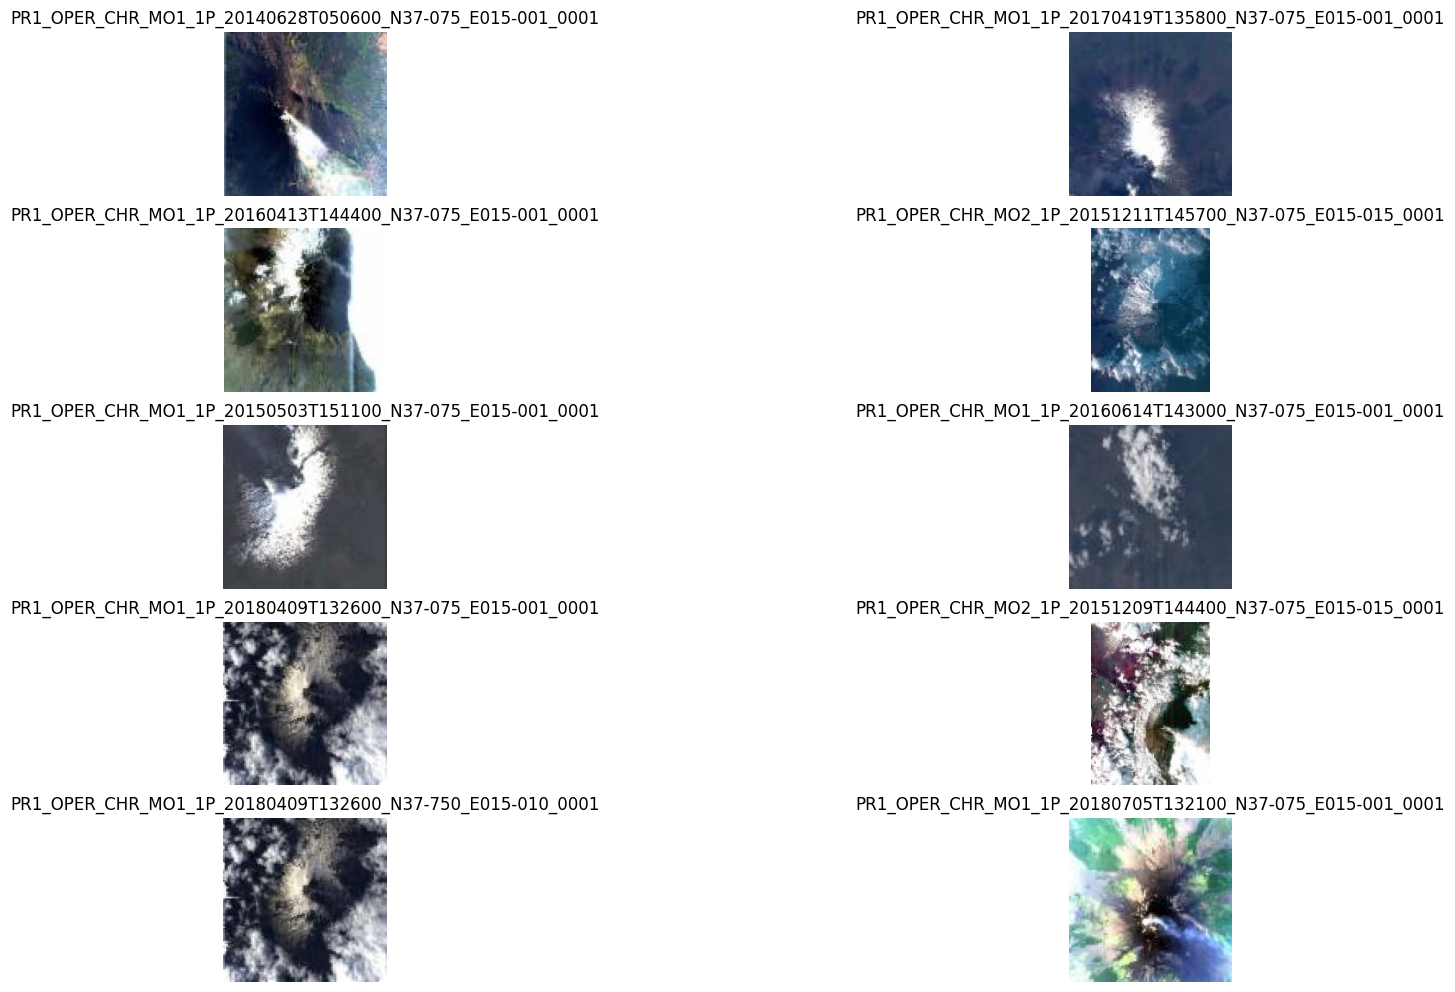

In [84]:
display_previews(results)

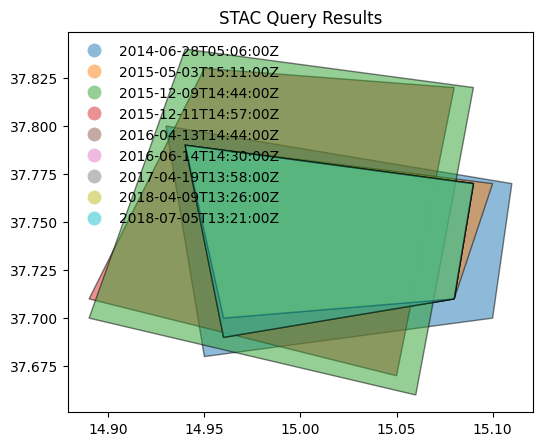

In [85]:
display_gdf_plot(results)

In [86]:
display_map(results)

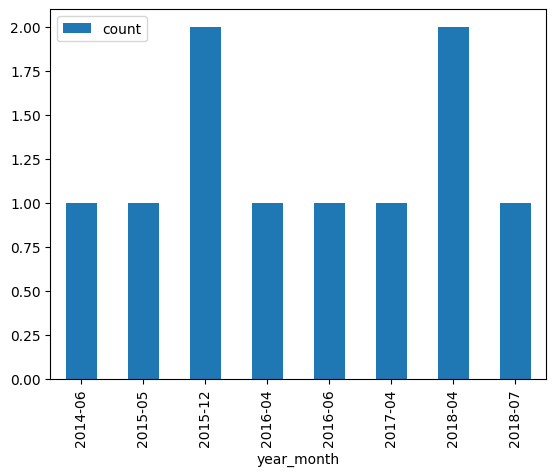

In [87]:
display_date_distribution(results)

**Example: 2.4**  
>  Search granules by bounding box {bbox} [[RD11]](#RD11).  Geometry parameter is provided as Python tuple.

In [88]:
# x, y = (14.95, 37.74)   # Center point of query (Mount Etna)
x, y = (4.38, 51.25)   # Center point of query (Antwerp harbour) 

r = 0.1
box = (x - r, y - r, x + r, y + r)

from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items=10,
    collections=[COLLECTION_ID1],
    bbox = box
)

Same request using `curl`.

In [89]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "bbox=4.28,51.15,4.4799999999999995,51.35" \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


In [90]:
print(f"{results.matched()} items found.")

8 items found.


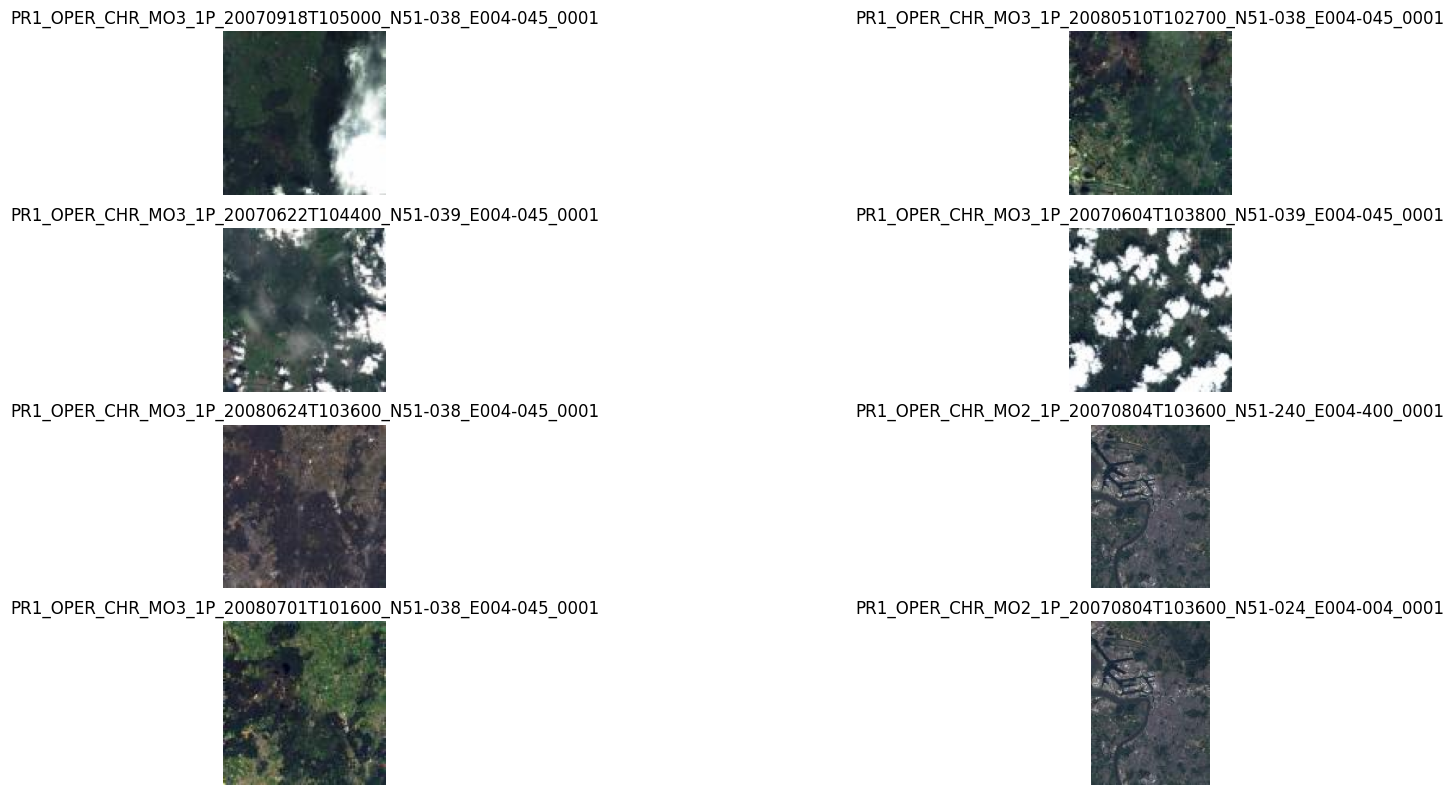

In [91]:
display_previews(results)

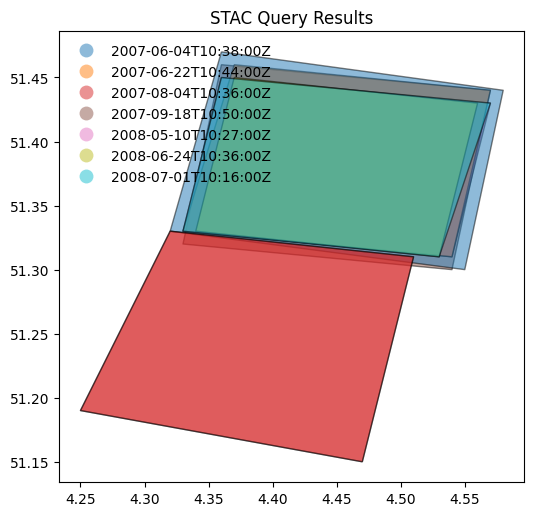

In [92]:
display_gdf_plot(results)

In [93]:
display_map(results)

**Example: 2.5**  
>  Search granules by bounding box (`bbox`) and generate density map. 

In [94]:
collection_id = COLLECTION_ID1

def get_results(bbox):
    x, y, x2, y2 = bbox
    results = api.search(
            method = 'GET',   
            max_items=1, 
            bbox = [x, y, x2, y2], 
            collections=[collection_id]
    ) 
    return results.matched()

collection_size = get_results([-180, -90, 180, 90])

In [95]:
n_rows = 18
n_columns = 36

dy = 180.0 / n_rows
dx = 360.0 / n_columns
shape = (n_rows, n_columns)
Z = np.zeros(shape)

bboxes = []
for col in range(n_columns):
    for row in range(n_rows):
        x = col * dx - 180.0
        y = row * dy - 90.0
        bboxes.append((x, y, x+dx, y+dy))

In [96]:
%%time
executor = ThreadPoolExecutor(max_workers=32)

results = executor.map(get_results, bboxes)

for col in range(n_columns):
    for row in range(n_rows):
        count = next(results)
        Z[row, col] = count

CPU times: total: 43 s
Wall time: 13 s


In [97]:
print(f'Display number of granules as density map of {n_rows} rows ({dy}°) by {n_columns} columns ({dx}°).')

Display number of granules as density map of 18 rows (10.0°) by 36 columns (10.0°).


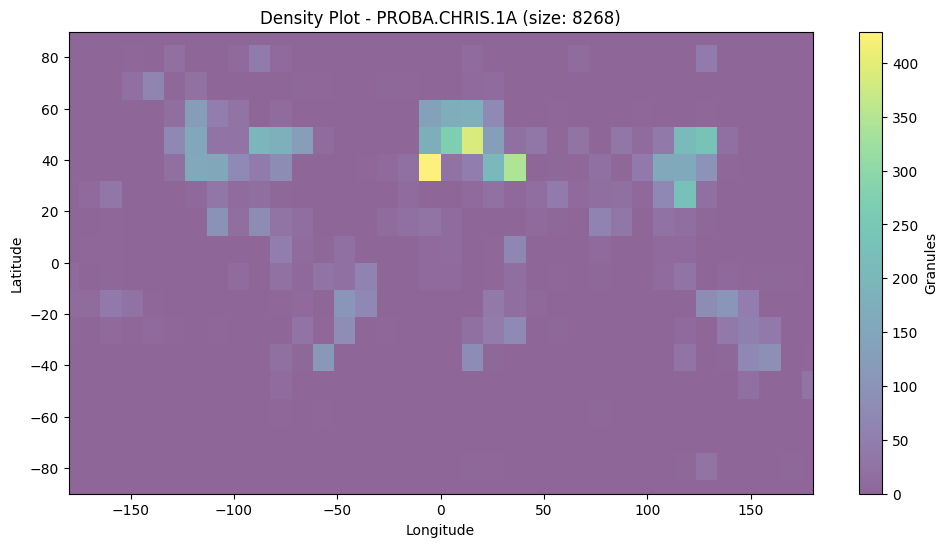

In [98]:
# Get world map data from Geopandas
# worldmap = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Create axes and plot world map
fig, ax = plt.subplots(figsize=(12, 6))
# worldmap.plot(color="lightgrey", ax=ax)

side_x = np.linspace(-180, +180, n_columns)
side_y = np.linspace(-90, +90, n_rows)
X, Y = np.meshgrid(side_x, side_y)
# Z was computed before.
plt.pcolormesh(X, Y, Z, shading='auto', alpha=0.6)
plt.colorbar(label='Granules')

# Create axis limits and title
plt.xlim([-180, 180])
plt.ylim([-90, 90])

plt.title("Density Plot - " + collection_id + " (size: "+str(collection_size)+")")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

```{index} double: STAC API ; datetime
```
```{index} double: pystac_client ; datetime
```

### Search by temporal extent

**Example: 2.6**  
>  Search granules by date range (datetime) [[RD01]](#RD01).  

In [99]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items = 50,
    collections=[COLLECTION_ID1],
    datetime=['2019-01-01T00:00:00Z', '2019-12-02T00:00:00Z']
)

In [100]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "datetime=2019-01-01T00:00:00Z/2019-12-02T00:00:00Z" \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


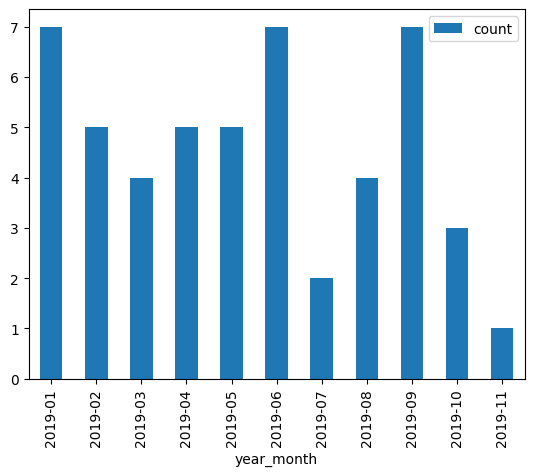

In [101]:
display_date_distribution(results)

**Example: 2.7**  
>  Search granules by open-ended date range (datetime) [[RD01]](#RD01).  

In [102]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items = 50,
    collections=[COLLECTION_ID1],
    datetime=['2021-12-01T00:00:00Z', None]
)

In [103]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "datetime=2021-12-01T00:00:00Z/.." \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


In [104]:
print(f"{results.matched()} items found.")

510 items found.


In [105]:
# keep id of first granule for future use below.
items = list(results.items())
granule_id1 = items[0].id

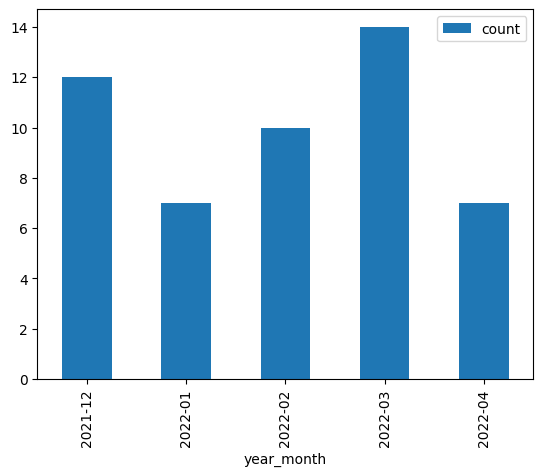

In [106]:
display_date_distribution(results)

In [107]:
display_value_distribution(results, 'sar:product_type')

sar:product_type values are not available.


```{index} double: STAC API ; ids
```

### Search by identifier


```{index} double: pystac_client ; ids
```
**Example: 2.8**  
>  Search granule by identifier (ids) [[RD01]](#RD01).  

In [108]:
granule_id1

'PR1_OPER_CHR_MO1_1P_20211211T115400_N33-720_E035-840_0001'

In [109]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    collections=[COLLECTION_ID1],
    ids=[granule_id1]
)

In [110]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "ids=PR1_OPER_CHR_MO1_1P_20211211T115400_N33-720_E035-840_0001" \
	--data-urlencode "collections=PROBA.CHRIS.1A"
```


In [111]:
items = list(results.items())
print(f"{results.matched()} items found.")
assert results.matched() == 1

# Convert STAC items into data frame
stac_json = results.item_collection_as_dict()
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")
gdf.transpose()

1 items found.


,0
geometry,"POLYGON ((35.91 33.68, 35.92 33.74, 35.77 33.7..."
grid:code,WRS-E035-N33
proj:code,EPSG:4326
time:published,2021-12-11T11:58:00Z
start_datetime,2021-12-11T11:54:00Z
end_datetime,2021-12-11T11:58:00Z
view:sun_azimuth,216.216307
product:type,CHR_MO1_1P
title,PR1_OPER_CHR_MO1_1P_20211211T115400_N33-720_E0...
platform,PROBA-1


```{index} double: STAC API ; filter
```

### Search with filter

```{index} double: pystac_client ; filter
```

**Example: 2.10**  
>  Search granules with filter {filter} [[RD01]](#RD01).  Available filters are advertised in `Queryables` object at /collections/{id}/queryables.

In [115]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items=10,
    collections=[COLLECTION_ID1],
    bbox = [14.90, 37.700, 14.99, 37.780], # Mount Etna
    datetime=['2015-01-01T00:00:00Z', '2022-01-02T00:00:00Z'],
    filter="productType='CHR_MO2_1P' and instrument='CHRIS'"
)

Same request with `curl`.

In [116]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "bbox=14.9,37.7,14.99,37.78" \
	--data-urlencode "datetime=2015-01-01T00:00:00Z/2022-01-02T00:00:00Z" \
	--data-urlencode "collections=PROBA.CHRIS.1A" \
	--data-urlencode "filter=productType='CHR_MO2_1P' and instrument='CHRIS'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [117]:
print(f"{results.matched()} items found.")

2 items found.


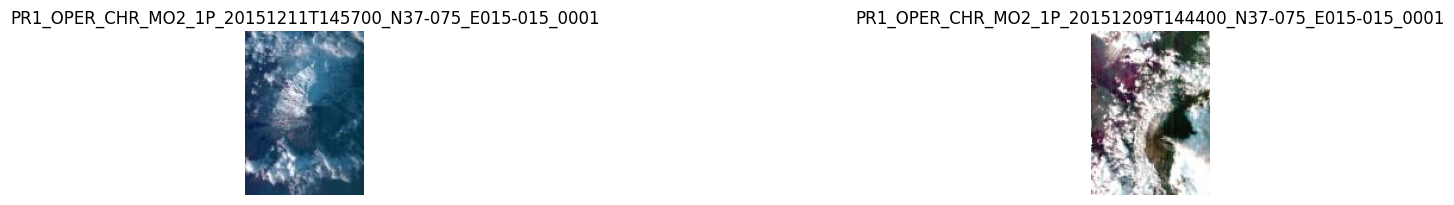

In [118]:
display_previews(results)

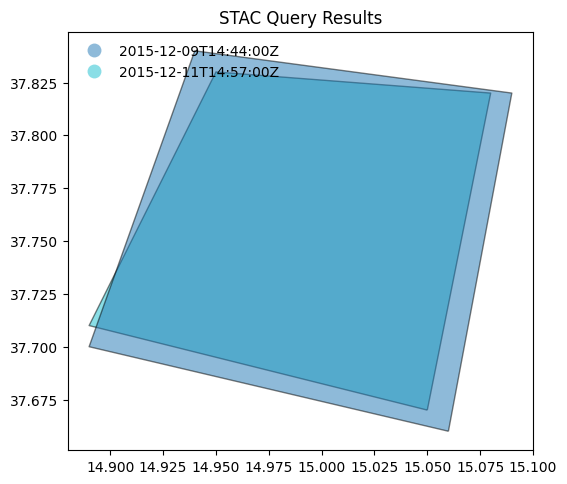

In [119]:
display_gdf_plot(results)

In [120]:
display_map(results)

In [121]:
display_value_distribution(results, 'sar:product_type')

sar:product_type values are not available.


### Search by cloud cover

**Example: 2.11**  
>  Search granules by cloudcover (`filter` and `cloudCover`) [[RD01]](#RD01).  Available filters are advertised in `Queryables` object at /collections/{id}/queryables.

In [122]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE)  

results = api.search(
    method = 'GET',   
    max_items=50,
    collections=[COLLECTION_ID3_CLOUDS],
    filter="cloudCover < 10"    
)

In [123]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "collections=IKONOS.ESA.archive" \
	--data-urlencode "filter=cloudCover < 10" \
	--data-urlencode "filter-lang=cql2-text"
```


In [124]:
print(f"{results.matched()} items found.")

246 items found.


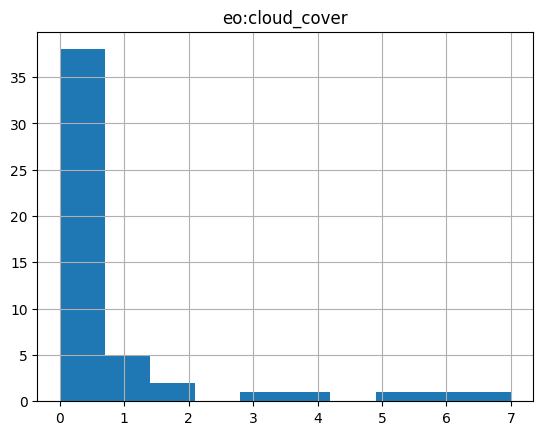

In [125]:
# Display cloud-cover values as histogram to show that range is taken into account
stac_json = results.item_collection_as_dict()
gdf = gpd.GeoDataFrame.from_features(stac_json)
try:
  _ = gdf[['title','eo:cloud_cover']].hist()
except:
  print("eo:cloud_cover information is not available.")

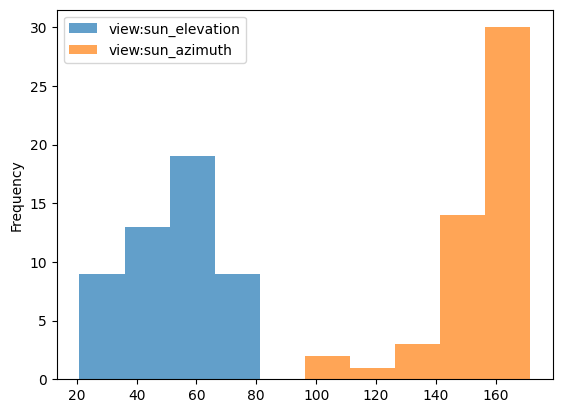

In [126]:
# fails if properties are not in the metadata.
try:
  # _ = gdf[['view:sun_elevation','view:incidence_angle','view:sun_azimuth']].plot.hist(alpha=0.7)
  _ = gdf[['view:sun_elevation','view:sun_azimuth']].plot.hist(alpha=0.7)
except:
  print("acquisition angle information is not available.")

In [127]:
# gdf

In [128]:
# display_value_distribution(results, 'sat:orbit_state')
display_value_distribution(results, 'sar:product_type')

sar:product_type values are not available.


### Search multiple collections

**Example: 2.12**  
>  Search granules in multiple collections {collections} [[RD01]](#RD01).  

In [129]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'GET',   
    max_items=10,
    collections=[COLLECTION_ID2_CLOUDS, COLLECTION_ID1],
    bbox = [13.90, 36.700, 15.99, 38.780], # Mount Etna (large)
)

In [130]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "bbox=13.9,36.7,15.99,38.78" \
	--data-urlencode "collections=LANDSAT.ETM.GTC,PROBA.CHRIS.1A"
```


In [131]:
print(f"{results.matched()} items found.")

797 items found.


**Example: 2.13**  
>  Search granules in multiple collections {collections} [[RD01]](#RD01) using `POST`. 

In [132]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE) 

results = api.search(
    method = 'POST',    
    max_items=50,
    collections=[COLLECTION_ID2_CLOUDS, COLLECTION_ID1],
    bbox = [13.90, 36.700, 15.99, 38.780] # Mount Etna (large)
)

In [133]:
curl_str = curl_command(results.url_with_parameters(),'POST')
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X POST https://fedeo.ceos.org/search \
	--header 'Content-Type: application/json' \
	--data-raw '{
		"bbox": "13.9,36.7,15.99,38.78",
		"collections": ["LANDSAT.ETM.GTC", "PROBA.CHRIS.1A"]
	}'
```


In [134]:
print(f"{results.matched()} items found.")

797 items found.


## Granule properties

Granules are returned via `item` links in the Catalog or Collection objects, or via the STAC API (Feature).
 An item is a GeoJSON `Feature` and the encoding is derived from the original OGC 17-003r2 encoding 
 according to a [documented mapping](https://github.com/stac-utils/stac-crosswalks/tree/master/OGC_17-003r2).
     
 The properties available include attributes from STAC extensions as well:    
  
 * [Item fields](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md#item-fields) 
 * [Common metadata elements](https://github.com/radiantearth/stac-spec/blob/master/item-spec/common-metadata.md) 
 * [EO Extension](https://github.com/stac-extensions/eo)
 * [SAR Extension](https://github.com/stac-extensions/sar)
 * [SAT Extension](https://github.com/stac-extensions/sat)
 * [Scientific Extension](https://github.com/stac-extensions/scientific)   
 * [Version Extension](https://github.com/stac-extensions/version)
 * [View Extension](https://github.com/stac-extensions/view)
 * [Projection Extension](https://github.com/stac-extensions/projection)
 * [Timestamps Extension](https://github.com/stac-extensions/timestamps)
 * [Landsat Extension](https://landsat.usgs.gov/stac/landsat-extension/schema.json)   



```{index} double: pystac_client ; assets
```
```{index} double: STAC API ; assets 
```
```{index} double: STAC API ; thumbnail 
```
```{index} double: STAC API ; data 
```
```{index} double: STAC API ; metadata 
```
```{index} double: assets ; OGC 10-157r4 
```
```{index} double: assets ; OGC 17-003r2 
```

### Assets

Granules provide access to a dictionary with `assets`.  The `roles` attribute indicates the purpose of the asset. The `href` attribute provides the URL to access the asset.  Granule assets include `thumbnail` (when available), a `data` download link (equivalent to the rel=`enclosure`), and various `metadata` formats.

The table below list some frequently used `metadata` formats and their corresponding media type (`type`).

| Format                   | type |   
| --------                   | --------- | 
| [ISO19139](https://www.iso.org/standard/32557.html)        | application/vnd.iso.19139+xml |  
| [ISO19139-2](https://www.iso.org/standard/57104.html)      | application/vnd.iso.19139-2+xml | 
| [ISO19115-3](https://www.iso.org/standard/32579.html)      | application/vnd.iso.19115-3+xml | 
| [OGC 10-157r4](https://docs.opengeospatial.org/is/10-157r4/10-157r4.html)  | application/gml+xml;profile=http://www.opengis.net/spec/EOMPOM/1.1  |
| [OGC 17-003r2](https://docs.opengeospatial.org/is/17-003r2/17-003r2.html)  | application/geo+json;profile=http://www.opengis.net/spec/eo-geojson/1.0  |

In [135]:
# Show assets of first search result (GeoJSON)
data = results.item_collection_as_dict()
jstr = json.dumps(data['features'][1]['assets'], indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "thumbnail": {
      "roles": [
         "thumbnail"
      ],
      "href": "http://landsat-diss.eo.esa.int/oads/meta/LandsatETM/thumbnail/L07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E_v0100.SIP.ZIP_TIMG.jpg",
      "type": "image/jpeg",
      "title": "THUMBNAIL"
   },
   "enclosure": {
      "roles": [
         "data"
      ],
      "href": "https://landsat-diss.eo.esa.int/oads/data/LandsatETM/L07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E_v0100.SIP.ZIP",
      "type": "application/zip",
      "title": "Download",
      "file:size": 318047520
   },
   "metadata_ogc_10_157r4": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/LANDSAT.ETM.GTC/items/LS07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E?httpAccept=application/gml%2Bxml&recordSchema=om",
      "title": "OGC 10-157r4 metadata",
      "type": "application/gml+xml;profile=\"http://www.opengis.net/spec/EOMPOM/1.1\""
   },
   "metadata_ogc_17_069r3": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/LANDSAT.ETM.GTC/items/LS07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E",
      "title": "OGC 17-069r3 metadata",
      "type": "application/geo+json;profile=\"http://www.opengis.net/spec/ogcapi-features-1/1.0\""
   },
   "metadata_ogc_17_003r2": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/LANDSAT.ETM.GTC/items/LS07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E?mode=owc",
      "title": "OGC 17-003r2 metadata",
      "type": "application/geo+json;profile=\"http://www.opengis.net/spec/eo-geojson/1.0\""
   },
   "metadata_iso_19139": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/LANDSAT.ETM.GTC/items/LS07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E?httpAccept=application/vnd.iso.19139%2Bxml",
      "title": "ISO 19139 metadata",
      "type": "application/vnd.iso.19139+xml"
   },
   "metadata_html": {
      "roles": [
         "metadata"
      ],
      "href": "https://fedeo.ceos.org/collections/LANDSAT.ETM.GTC/items/LS07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E?httpAccept=text/html",
      "title": "HTML",
      "type": "text/html"
   },
   "quicklook": {
      "roles": [
         "overview"
      ],
      "href": "http://landsat-diss.eo.esa.int/oads/meta/LandsatETM/browse/L07_RFUI_ETM_GTC_1P_19990724T092836_19990724T092905_001453_0188_0034_463E_v0100.SIP.ZIP_BID.PNG",
      "type": "image/png",
      "title": "QUICKLOOK"
   }
}
```


In [136]:
df = pd.DataFrame(columns=['roles', 'title', 'type'])
    
# Display assets belonging to first item in results
for item in results.items():
    assets = item.assets
    for key in assets:     
        ndf = pd.DataFrame({ 
            'roles': assets[key].roles, 
            'type': assets[key].media_type, 
            'title': assets[key].title, 
            # 'href': assets[key].href  
        }, index = [0])
        df = pd.concat([df, ndf], ignore_index=True)
    
    break
df

,roles,title,type
0,thumbnail,THUMBNAIL,image/jpeg
1,data,Download,application/zip
2,metadata,OGC 10-157r4 metadata,"application/gml+xml;profile=""http://www.opengi..."
3,metadata,OGC 17-069r3 metadata,"application/geo+json;profile=""http://www.openg..."
4,metadata,OGC 17-003r2 metadata,"application/geo+json;profile=""http://www.openg..."
5,metadata,ISO 19139 metadata,application/vnd.iso.19139+xml
6,metadata,HTML,text/html
7,overview,QUICKLOOK,image/png


## Advanced topics

```{index} double: STAC API ; conformsTo
```

### Conformance classes

The conformance classes supported by the STAC interface are advertised in the `conformsTo` property of the landing page.

In [137]:
response = requests.get(URL_LANDING_PAGE)

data = json.loads(response.text)
jstr = json.dumps(data['conformsTo'], indent=3)
md("```json\n" + jstr + "\n```\n")

```json
[
   "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/core",
   "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/oas30",
   "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/geojson",
   "http://www.opengis.net/spec/ogcapi_common-2/1.0/conf/collections",
   "http://www.opengis.net/spec/ogcapi-common-2/1.0/conf/simple-query",
   "http://www.opengis.net/spec/ogcapi-records-1/1.0/req/cql-filter",
   "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/geojson",
   "http://www.opengis.net/spec/ogcapi-features-3/1.0/conf/features-filter",
   "https://api.stacspec.org/v1.0.0-rc.2/core",
   "https://api.stacspec.org/v1.0.0-rc.2/stac-search",
   "https://api.stacspec.org/v1.0.0-rc.2/stac-response",
   "https://api.stacspec.org/v1.0.0-rc.2/collection-search",
   "https://api.stacspec.org/v1.0.0-rc.2/collection-search#filter",
   "https://api.stacspec.org/v1.0.0-rc.1/collection-search#free-text",
   "https://api.stacspec.org/v1.0.0-rc.2/item-search",
   "https://api.stacspec.org/v1.0.0-rc.2/item-search#filter",
   "http://www.opengis.net/spec/cql2/1.0/conf/cql2-text",
   "http://www.opengis.net/spec/cql2/1.0/conf/basic-cql2"
]
```


### Additional search parameters


In [138]:
md(f'Additional search parameters beyond the STAC search parameters can be used to filter collection search results. The available parameters for collection search are advertised at {URL_LANDING_PAGE + "collections/queryables"} and represented as a JSON Schema.')

Additional search parameters beyond the STAC search parameters can be used to filter collection search results. The available parameters for collection search are advertised at https://fedeo.ceos.org/collections/queryables and represented as a JSON Schema.

In [139]:
URL_QUERYABLES = URL_LANDING_PAGE + 'collections/queryables'

In [140]:
curl_str = curl_command(URL_QUERYABLES)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections/queryables
```


In [141]:
response = requests.get(URL_QUERYABLES)   
data = json.loads(response.text)    
df = pd.DataFrame(data['properties'].items(),columns=['key','value'])
df['type'] = df.apply(lambda row : row['value']['type'], axis = 1)
df['format'] = df.apply(lambda row : row['value']['format'] if 'format' in row['value'] else '-' , axis = 1)
df.drop('value',axis=1).sort_values(by=['key'])

,key,type,format
14,classifiedAs,string,uri
13,doi,string,-
3,instrument,string,-
8,modificationDate,string,date-time
11,offering,string,-
7,organisationName,string,-
5,otherConstraint,string,-
2,parentIdentifier,string,-
6,platform,string,-
9,processingLevel,string,-


In [142]:
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "$schema": "https://json-schema.org/draft/2019-09/schema",
   "description": "Queryable names for the STAC API Collection Search filter.",
   "type": "object",
   "title": "Queryables for the STAC API",
   "properties": {
      "subject": {
         "description": "{dc:subject}",
         "title": "Subject",
         "type": "string"
      },
      "query": {
         "description": "{os:searchTerms}",
         "title": "Query",
         "type": "string"
      },
      "parentIdentifier": {
         "description": "{eo:parentIdentifier}",
         "title": "Parent identifier",
         "type": "string",
         "enum": [
            "EOP:DLR:GEOSERVICE",
            "EOP:ESA:EARTH-ONLINE",
            "EOP:ESA:ECV",
            "EOP:ESA:MAAP",
            "EOP:EU:CDSE",
            "EOP:EU:CMEMS",
            "EOP:EUMETSAT",
            "EOP:INPE:DATA",
            "EOP:JAXA:G-PORTAL",
            "EOP:NRCAN:EODMS",
            "EOP:NRSC:BHOONIDHI",
            "EOP:STFC:CEDA-CCI",
            "EOP:VITO:GLOBALLAND",
            "EOP:VITO:TERRASCOPE",
            "EOP:NASA:CMR"
         ]
      },
      "instrument": {
         "description": "{eo:instrument}",
         "title": "Instrument",
         "type": "string",
         "enum": [
            "GEOTON-L1",
            "GSA",
            "MSS",
            "PSS",
            "SHMSA_SR",
            "SHMSA_VR",
            "AATSR",
            "ABI",
            "ACC",
            "ACE-FTS",
            "ACGS",
            "AIRSAFE",
            "ALADIN",
            "ALTIKA",
            "AMI/SAR",
            "AMI/Scatterometer",
            "AMSR",
            "AMSR-E",
            "AMSR2",
            "AMSU-B",
            "ASAR",
            "ASCAT",
            "ASM",
            "ASTER",
            "ATLID",
            "ATSR-1",
            "ATSR-2",
            "AVHRR",
            "AVHRR-2",
            "AVHRR-3",
            "AVNIR",
            "AVNIR-2",
            "AwiFS",
            "BBR",
            "BGI",
            "BLACKJACK",
            "BUV",
            "C-SAR",
            "CALIOP",
            "CAPI",
            "CHRIS",
            "CIRC",
            "CPR",
            "CSG-SAR",
            "DESIS",
            "DORIS",
            "DPR",
            "EFI",
            "EGG",
            "EOC",
            "ETM",
            "GEOTON-L1",
            "GERB",
            "GIS",
            "GLI",
            "GMI",
            "GOES I-M IMAGER",
            "GOES N-P IMAGER",
            "GOES-13 IMAGER",
            "GOME",
            "GOME-2",
            "GOMOS",
            "GPSR",
            "GRACE ACC",
            "GRACE INTERFEROMETER",
            "GRACE LRR",
            "GRACE SCA",
            "GRAS",
            "GSA",
            "HALOE",
            "HIRS/2",
            "HIRS/3",
            "HIRS/4",
            "HRC",
            "HRG",
            "HRS",
            "HRV",
            "HRVIR",
            "HSI",
            "HiRAIS",
            "HiRI",
            "HyperScout-2",
            "IASI",
            "IIR",
            "JAMI",
            "KBR",
            "LIMS",
            "LISS-3",
            "LISS-4",
            "LRR",
            "MAESTRO",
            "MERIS",
            "MESSR",
            "MGM",
            "MHS",
            "MIPAS",
            "MIRAS",
            "MODIS",
            "MSC",
            "MSI",
            "MSS",
            "MTSAT 2 IMAGER",
            "MVIRI",
            "MWHS-1",
            "MWR",
            "NAOMI",
            "NRA",
            "OCM-2",
            "OCTS",
            "OLCI",
            "OLI Instrument",
            "OLI",
            "OLI-2",
            "OLS",
            "OMI",
            "OPS",
            "OSA",
            "OSCAT",
            "OSIRIS",
            "P-SAR",
            "PALSAR",
            "PAN",
            "PANMUX",
            "PAZ-SAR",
            "PNEO",
            "POAM-II",
            "POAM-III",
            "POLDER",
            "POSEIDON-2",
            "POSEIDON-3",
            "PR",
            "PRARE",
            "PRISM",
            "PSS",
            "PlanetScope Camera",
            "RA",
            "RA-2",
            "RBV",
            "SAGE-I",
            "SAOCOM-SAR",
            "SAPHIR",
            "SAR",
            "SBUV",
            "SBUV/2",
            "SCARAB",
            "SCAT",
            "SCIAMACHY",
            "SENSE",
            "SEVIRI",
            "SGLI",
            "SHMSA_SR",
            "SHMSA_VR",
            "SIM",
            "SIRAL",
            "SLIM6",
            "SLSTR",
            "SMMR",
            "SMR",
            "SOLSTICE",
            "SRAL",
            "SSALT",
            "SSM/I",
            "SSM/T-2",
            "SSMIS",
            "SSTI",
            "SSTL S1-4",
            "STR",
            "STRATOS",
            "SWIM",
            "SeaWiFS",
            "SeaWinds",
            "SkySat Camera",
            "SpaceView-110",
            "TANSO-CAI",
            "TANSO-CAI-2",
            "TANSO-FTS",
            "TANSO-FTS-2",
            "TDX-1",
            "TIM",
            "TIROS-N",
            "TIRS",
            "TIRS-2",
            "TM",
            "TMI",
            "TOMS",
            "TROPOMI",
            "TSX-1",
            "VAS",
            "VFM",
            "VG1",
            "VG2",
            "VGT",
            "VHRR",
            "VIIRS",
            "VISSR",
            "VISSR-GMS",
            "VTIR",
            "WAF-P",
            "WFC",
            "WFI",
            "WIF",
            "WINDSAT",
            "WPM",
            "WV110",
            "WV60",
            "X-SAR"
         ]
      },
      "title": {
         "description": "{dc:title}",
         "title": "Title",
         "type": "string"
      },
      "otherConstraint": {
         "description": "{eo:otherConstraint}",
         "title": "Other constraint",
         "type": "string"
      },
      "platform": {
         "description": "{eo:platform}",
         "title": "Platform",
         "type": "string",
         "enum": [
            "ADEOS-I",
            "ADEOS-II",
            "AEM-2",
            "ALOS",
            "ALOS-1",
            "ALOS-2",
            "AQUA",
            "Aeolus",
            "Amazonia-1",
            "Aura",
            "BIROS",
            "Beijing-1",
            "BelKA",
            "Biomass",
            "CALIPSO",
            "CBERS",
            "CBERS-2B",
            "CBERS-4",
            "CBERS-4A",
            "CFOSAT",
            "CHAMP",
            "COSMO-SkyMed Second Generation",
            "COSMO-SkyMed",
            "CloudSat",
            "CryoSat-2",
            "DMSP 5D-1/F2",
            "DMSP 5D-1/F3",
            "DMSP 5D-1/F4",
            "DMSP 5D-2/F10",
            "DMSP 5D-2/F11",
            "DMSP 5D-2/F12",
            "DMSP 5D-2/F13",
            "DMSP 5D-2/F14",
            "DMSP 5D-2/F8",
            "DMSP 5D-3/F15",
            "DMSP 5D-3/F16",
            "DMSP 5D-3/F17",
            "DMSP 5D-3/F18",
            "DMSP 5D-3/F19",
            "ERS-1",
            "ERS-2",
            "EarthCARE",
            "Elektro-L-N1",
            "EnMAP",
            "Envisat",
            "FORMOSAT-2",
            "FSSCAT",
            "FY-3A",
            "FY-3B",
            "FY-3C",
            "FireBIRD",
            "GCOM-C1",
            "GCOM-W1",
            "GEOSAT-1",
            "GEOSAT-2",
            "GHGSat-C1",
            "GHGSat-C2",
            "GMS-1",
            "GMS-2",
            "GMS-3",
            "GMS-4",
            "GMS-5",
            "GOCE",
            "GOES",
            "GOES-1",
            "GOES-10",
            "GOES-11",
            "GOES-12",
            "GOES-13",
            "GOES-14",
            "GOES-15",
            "GOES-16",
            "GOES-19",
            "GOES-2",
            "GOES-3",
            "GOES-4",
            "GOES-5",
            "GOES-6",
            "GOES-7",
            "GOES-8",
            "GOES-9",
            "GOSAT-1",
            "GOSAT-2",
            "GPM",
            "GRACE",
            "GeoEye-1",
            "ICEYE",
            "IKONOS",
            "IKONOS-2",
            "IRS-1C",
            "IRS-1D",
            "IRS-P5",
            "IRS-P6",
            "IRS-R2",
            "ISS",
            "JERS-1",
            "JPSS-1",
            "Jason-1",
            "Jason-2",
            "KANOPUS_V1",
            "KOMPSAT-1",
            "KOMPSAT-2",
            "Landsat",
            "Landsat-1",
            "Landsat-2",
            "Landsat-3",
            "Landsat-4",
            "Landsat-5",
            "Landsat-7",
            "Landsat-8",
            "Landsat-9",
            "METEOR-3M",
            "MFG",
            "MONITOR-E",
            "MOS-1A",
            "MOS-1B",
            "MSG",
            "MTSAT-1R",
            "MTSAT-2",
            "Megha-Tropiques",
            "Meteosat-10",
            "Meteosat-11",
            "Meteosat-2",
            "Meteosat-3",
            "Meteosat-4",
            "Meteosat-5",
            "Meteosat-6",
            "Meteosat-7",
            "Meteosat-8",
            "Meteosat-9",
            "Metop-A",
            "Metop-B",
            "Metop-C",
            "NISAR",
            "NOAA POES",
            "NOAA-10",
            "NOAA-11",
            "NOAA-12",
            "NOAA-14",
            "NOAA-15",
            "NOAA-16",
            "NOAA-17",
            "NOAA-18",
            "NOAA-19",
            "NOAA-2",
            "NOAA-20",
            "NOAA-3",
            "NOAA-4",
            "NOAA-5",
            "NOAA-6",
            "NOAA-7",
            "NOAA-8",
            "NOAA-9",
            "NigeriaSat-1",
            "Nimbus-4",
            "Nimbus-7",
            "ODIN",
            "OceanSat-2",
            "OrbView-2",
            "PAZ",
            "PROBA-1",
            "PROBA-V",
            "Parasol-1",
            "PlanetScope",
            "Pleiades Neo",
            "Pleiades",
            "Pleiades-1A",
            "Pleiades-1B",
            "QUICKBIRD",
            "QuickBird-2",
            "QuikSCAT",
            "RADARSAT-1",
            "RADARSAT-2",
            "RESURS-DK1",
            "RESURS-P1",
            "RESURS-P2",
            "Radarsat",
            "RapidEye",
            "SAOCOM-1A",
            "SAOCOM-1B",
            "SARAL",
            "SCISAT-1",
            "SMOS",
            "SMS-1",
            "SMS-2",
            "SORCE",
            "SPACE SHUTTLES",
            "SPOT 1",
            "SPOT 2",
            "SPOT 4",
            "SPOT 5",
            "SPOT",
            "SPOT-1",
            "SPOT-2",
            "SPOT-3",
            "SPOT-4",
            "SPOT-5",
            "SPOT-6",
            "SPOT-7",
            "Seasat",
            "Sentinel-1",
            "Sentinel-1A",
            "Sentinel-1B",
            "Sentinel-1C",
            "Sentinel-1D",
            "Sentinel-2",
            "Sentinel-2B",
            "Sentinel-2C",
            "Sentinel-3",
            "Sentinel-3A",
            "Sentinel-3B",
            "Sentinel-5",
            "Sentinel-5P",
            "Sentinel-6A",
            "SkySat",
            "Spire",
            "Swarm",
            "TERRA",
            "TET-1",
            "TIROS-N",
            "TOPEX/POSEIDON",
            "TRMM",
            "TanDEM-X",
            "TanSat",
            "TerraSAR-X",
            "UARS",
            "UK-DMC-1",
            "Vision-1",
            "WindSat",
            "WorldView-1",
            "WorldView-2",
            "WorldView-3",
            "WorldView-4"
         ]
      },
      "organisationName": {
         "description": "{eo:organisationName}",
         "title": "Organisation name",
         "type": "string",
         "enum": [
            "ASF",
            "Airbus Defence and Space Geo",
            "Airbus Defence and Space",
            "BR/INPE",
            "CA/NRCAN/ESS",
            "CEDA",
            "CMEMS",
            "CloudFerro",
            "Copernicus Land Monitoring Service (CLMS)",
            "Copernicus Land Monitoring Service",
            "DE/DLR",
            "DOC/NOAA",
            "DOC/NOAA/NESDIS/NCEI",
            "DOI/USGS",
            "EC",
            "ECMWF",
            "ESA/ESRIN",
            "EU/C3S",
            "EUMETSAT",
            "EUMETSAT/OSISAF",
            "European Environment Agency (EEA)",
            "European Environment Agency",
            "FR/CNES",
            "FR/Meteo-France",
            "IN/ISRO/NDC",
            "JP/JAXA/SAOC",
            "JP/JMA",
            "Japan Aerospace Exploration Agency (JAXA)",
            "Laboratoire d'Oc\u00e9anologie et de G\u00e9osciences",
            "NASA JPL",
            "NASA",
            "NASA/JPL (SRTM)",
            "NL/KNMI",
            "NO/MET",
            "NRSC",
            "Natural Resources Canada",
            "OpenGeoHub Foundation",
            "OpenGeoHub",
            "OpenTopography",
            "ROSCOSMOS",
            "SatOC",
            "Sinergise",
            "UC-LONDON/CPOM",
            "UK/CCLRC/RAL",
            "USGS",
            "VITO"
         ]
      },
      "modificationDate": {
         "format": "date-time",
         "description": "{eo:modificationDate}",
         "title": "Modification date",
         "type": "string"
      },
      "processingLevel": {
         "description": "{eo:processingLevel}",
         "title": "Processing level",
         "type": "string",
         "enum": [
            "level 0",
            "level 1",
            "level 1.5",
            "level 1a",
            "level 1b",
            "level 1b+",
            "level 1c",
            "level 1d",
            "level 1g",
            "level 1gt",
            "level 1r",
            "level 1t",
            "level 2",
            "level 2a",
            "level 2b",
            "level 2c",
            "level 3",
            "level 3a",
            "level 3b",
            "level 4",
            "level-a",
            "level-a+",
            "multiple"
         ]
      },
      "useLimitation": {
         "description": "{eo:useLimitation}",
         "title": "Use limitation",
         "type": "string"
      },
      "offering": {
         "description": "{eo:offering}",
         "title": "Offering",
         "type": "string"
      },
      "publisher": {
         "description": "{dc:publisher}",
         "title": "Publisher",
         "type": "string"
      },
      "doi": {
         "description": "{eo:doi}",
         "title": "Doi",
         "type": "string"
      },
      "classifiedAs": {
         "format": "uri",
         "description": "{semantic:classifiedAs}",
         "title": "Classified as",
         "type": "string"
      }
   },
   "$id": "https://fedeo.ceos.org/collections/queryables"
}
```


Additional search parameters beyond the STAC search parameters can be used to filter granule search results.  The available parameters for granule search are advertised for each individual collection and represented as a JSON Schema.

In [143]:
URL_COLLECTION_QUERYABLES = URL_LANDING_PAGE + 'collections/' + COLLECTION_ID1 + '/queryables'

md(f"For example, the collection `{COLLECTION_ID1}`, advertises its search parameters \
at {URL_COLLECTION_QUERYABLES} in JSON Schema format. Therefore, the following parameters can be used within a filter expression.")

For example, the collection `PROBA.CHRIS.1A`, advertises its search parameters at https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/queryables in JSON Schema format. Therefore, the following parameters can be used within a filter expression.

Get filter parameters for granule search

In [144]:
curl_str = curl_command(URL_COLLECTION_QUERYABLES)
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/queryables
```


In [145]:
response = requests.get(URL_COLLECTION_QUERYABLES)   
data = json.loads(response.text)    
df = pd.DataFrame(data['properties'].items(),columns=['key','value'])
df['type'] = df.apply(lambda row : row['value']['type'], axis = 1)
df['format'] = df.apply(lambda row : row['value']['format'] if 'format' in row['value'] else '-' , axis = 1)
df.drop('value',axis=1).sort_values(by=['key'])

,key,type,format
0,acquisitionType,string,-
5,availabilityTime,string,-
13,frame,string,-
1,illuminationAzimuthAngle,number,-
11,illuminationElevationAngle,number,-
2,instrument,string,-
7,modificationDate,string,date-time
4,orbitNumber,integer,-
3,platform,string,-
6,platformSerialIdentifier,string,-


In [146]:
jstr = json.dumps(data, indent=3)
md("```json\n" + jstr + "\n```\n")

```json
{
   "$schema": "https://json-schema.org/draft/2019-09/schema",
   "description": "Queryable names for the STAC API Item Search filter.",
   "type": "object",
   "title": "Queryables for PROBA.CHRIS.1A collection",
   "properties": {
      "acquisitionType": {
         "description": "{eo:acquisitionType}",
         "title": "Acquisition type",
         "type": "string",
         "enum": [
            "NOMINAL"
         ]
      },
      "illuminationAzimuthAngle": {
         "description": "{eo:illuminationAzimuthAngle}",
         "maximum": 360,
         "title": "Illumination azimuth angle",
         "type": "number",
         "minimum": 0
      },
      "instrument": {
         "description": "{eo:instrument}",
         "title": "Instrument",
         "type": "string",
         "enum": [
            "CHRIS"
         ]
      },
      "platform": {
         "description": "{eo:platform}",
         "title": "Platform",
         "type": "string",
         "enum": [
            "PROBA"
         ]
      },
      "orbitNumber": {
         "description": "{eo:orbitNumber}",
         "title": "Orbit number",
         "type": "integer"
      },
      "availabilityTime": {
         "description": "{eo:availabilityTime}",
         "title": "Availability time",
         "type": "string"
      },
      "platformSerialIdentifier": {
         "description": "{eo:platformSerialIdentifier}",
         "title": "Platform serial identifier",
         "type": "string",
         "enum": [
            "1"
         ]
      },
      "modificationDate": {
         "format": "date-time",
         "description": "{eo:modificationDate}",
         "title": "Modification date",
         "type": "string"
      },
      "productionStatus": {
         "description": "{eo:productionStatus}",
         "title": "Production status",
         "type": "string",
         "enum": [
            "ARCHIVED"
         ]
      },
      "track": {
         "description": "{eo:track}",
         "title": "Track",
         "type": "string"
      },
      "sensorMode": {
         "description": "{eo:sensorMode}",
         "title": "Sensor mode",
         "type": "string",
         "enum": [
            "MODE-1",
            "MODE-2",
            "MODE-3",
            "MODE-4",
            "MODE-5"
         ]
      },
      "illuminationElevationAngle": {
         "description": "{eo:illuminationElevationAngle}",
         "maximum": 180,
         "title": "Illumination elevation angle",
         "type": "number",
         "minimum": 0
      },
      "productType": {
         "description": "{eo:productType}",
         "title": "Product type",
         "type": "string",
         "enum": [
            "CHR_MO1_1P",
            "CHR_MO2_1P",
            "CHR_MO3_1P",
            "CHR_MO4_1P",
            "CHR_MO5_1P"
         ]
      },
      "frame": {
         "description": "{eo:frame}",
         "title": "Frame",
         "type": "string"
      }
   },
   "$id": "https://fedeo.ceos.org/collections/PROBA.CHRIS.1A/queryables"
}
```


### CQL filter expressions

```{index} double: STAC API ; cql-text
```

The STAC interface supports the `filter` parameter and filter expressions in `cql-text` filter format at the following endpoints:

- /collections
- /collections/{collection-id}/items
- /search

At the `/search` endpoint, it is required that a single collection can be determined from the `collections` or `ids` parameter.  The queryables allowed in the filter expression are then identical to the ones at the corresponding `/collections/{collection-id}/items/queryables` endpoint.  `filter` cannot be used at the `/search` endpoint when `collections` contains 0 or more than 1 collection identifiers.

Filter expressions are to be expressed with the Text encoding of the Basic Common Query Language (Basic CQL2-Text) [[RD22]](#RD22).
See the [OGC API Features "Conformance class Filter"](conformance-class-filter) section for CQL2 examples.

**Example: 8.1**  
>  CQL Filter for collection search with logical operators (and, or).

In [147]:
results = api.collection_search(
    filter = "platform = 'Envisat' and ( instrument = 'MERIS' or instrument = 'MIPAS' ) and organisationName = 'ESA/ESRIN'"
)

In [148]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/collections \
	--data-urlencode "filter=platform = 'Envisat' and ( instrument = 'MERIS' or instrument = 'MIPAS' ) and organisationName = 'ESA/ESRIN'" \
	--data-urlencode "filter-lang=cql2-text"
```


In [149]:
data = results.collection_list_as_dict()
df = pd.json_normalize(data, record_path=['collections'])
df[['id', 'title']]

,id,title
0,MER.RR__2P,Envisat MERIS Reduced Resolution Geophysical P...
1,ENVISAT.MIP.NL__1P,Envisat MIPAS L1 - Geo-located and calibrated ...
2,MER_FRS_1P,Envisat MERIS Full Resolution - Level 1 [MER_F...
3,11517,CLIMATE APPLICATIONS: Marine ecosystem dynamic...
4,11512,CLIMATE APPLICATIONS: Marine ecosystem dynamic...
5,11511,CLIMATE APPLICATIONS: Marine ecosystem dynamic...
6,11514,ESA Ocean Colour CCI version 3.0. CLIMATE APPL...
7,10481,ESA Land Cover Climate Change Initiative (Land...
8,11515,ESA Ocean Colour CCI version 3.0. CLIMATE APPL...
9,11508,ESA Ocean Colour CCI version 3.0. CLIMATE APPL...


**Example: 8.2**  
>  CQL filter for granule search with comparison operators.  Search granules with cloudCover between 10 and 15%. 

In [150]:
from pystac_client import Client 
api = Client.open(URL_LANDING_PAGE)  

results = api.search(
    method = 'GET',   
    max_items = 30,
    collections = [COLLECTION_ID3_CLOUDS],
    filter = "cloudCover >= 10 and cloudCover < 15"   
)

In [151]:
curl_str = curl_command(results.url_with_parameters())
md("```shell\n" + curl_str + "\n```\n")

```shell
curl -X GET -G https://fedeo.ceos.org/search \
	--data-urlencode "collections=IKONOS.ESA.archive" \
	--data-urlencode "filter=cloudCover >= 10 and cloudCover < 15" \
	--data-urlencode "filter-lang=cql2-text"
```


In [152]:
print(f"{results.matched()} items found.")

26 items found.


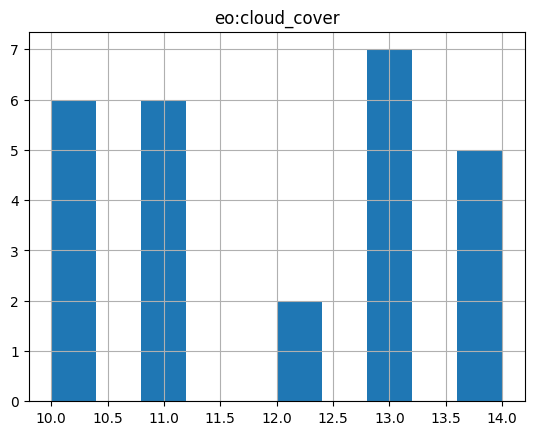

In [153]:
# Display cloud-cover values as histogram to show that range is taken into account
stac_json = results.item_collection_as_dict()
gdf = gpd.GeoDataFrame.from_features(stac_json)
try:
  _ = gdf[['title','eo:cloud_cover']].hist()
except:
  print("eo:cloud_cover information is not available.")

## Further Reading

| **ID**  | **Title** | 
| -------- | --------- | 
| `RD11` <a name="RD11"></a> | [STAC API - Item Search](https://github.com/radiantearth/stac-api-spec/tree/main/item-search) |
| `RD12` <a name="RD12"></a> | [STAC API - Filter Extension](https://github.com/stac-api-extensions/filter) |
| `RD13` <a name="RD13"></a> | [STAC Catalog Specification](https://github.com/radiantearth/stac-spec/blob/master/catalog-spec/catalog-spec.md) | 
| `RD14` <a name="RD14"></a> | [STAC Collection Specification](https://github.com/radiantearth/stac-spec/blob/master/collection-spec/collection-spec.md) | 
| `RD15` <a name="RD15"></a>| [STAC API Specification](https://github.com/radiantearth/stac-api-spec)  | 
| `RD16` <a name="RD16"></a> | [STAC Item Specification](https://github.com/radiantearth/stac-spec/tree/master/item-spec)   | 
| `RD17` <a name="RD17"></a> | [PySTAC Documentation](https://pystac.readthedocs.io/en/stable/) | 
| `RD18` <a name="RD18"></a> | [PySTAC Client Usage](https://pystac-client.readthedocs.io/en/stable/usage.html) | 
| `RD19` <a name="RD19"></a> | [ODC STAC - Plot STAC Items on a map ](https://odc-stac.readthedocs.io/en/latest/notebooks/stac-load-e84-aws.html#Plot-STAC-Items-on-a-Map) | 
| `RD20` <a name="RD20"></a> | [OGC17-069r3, OGC API - Features - Part 1: Core](https://docs.opengeospatial.org/is/17-069r3/17-069r3.html) | 
| `RD21` <a name="RD21"></a> | [OGC19-079r2, OGC API - Features - Part 3: Filtering](https://docs.opengeospatial.org/is/19-079r2/19-079r2.html)  | 
| `RD22` <a name="RD22"></a> | [OGC21-065r2, Common Query Language (CQL2)](https://docs.ogc.org/is/21-065r2/21-065r2.html)  | 
| `RD23` <a name="RD23"></a> | [RFC 7946 - The GeoJSON Format](https://datatracker.ietf.org/doc/html/rfc7946) | 
| `RD24` <a name="RD24"></a>| [JSON Schema: A Media Type for Describing JSON Documents, draft-handrews-json-schema-02](https://datatracker.ietf.org/doc/html/draft-handrews-json-schema-02) |
| `RD25` <a name="RD25"></a>| [STAC API - Collection Search](https://github.com/stac-api-extensions/collection-search) |






